In [ ]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import os
import json
import scvi
import seaborn as sns
import matplotlib.cm as cm

import decoupler as dc


from utils import preprocessing
from utils import label_mapping_utils as lmu

BASE_PATH = os.getenv("BASE_PATH_FOR_SAVING")

ADATA =  f'/home/gdallagl/myworkdir/data/XDP/SlideTags_dataset/all_lib_adata_zoned_ct-cured.h5ad'

SAMPLE = "sample_02" # sample_02, 03

sample_infos = {
    "sample_02": {"split_2_pucks_y": 30000, "slope_line": 1, "intercept_line": 47000, "flip_dead": False, "neun_pos_libraries": ["SI-TT-C1"]},
    "sample_03": {"split_2_pucks_y": 33000, "slope_line": 0.1, "intercept_line": 4000, "flip_dead": True, "neun_pos_libraries": ["SI-TT-C5"]},
}

SAMPLE_VARIABLE = "donor_id"
CONDITION_VARIABLE = "condition"
LOW_QUALITY_LABEL = "-Low_quality"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load

In [29]:
adata = sc.read_h5ad(ADATA, backed="r")

#s elcet a sample
adata = adata[adata.obs["donor_id"] == SAMPLE].to_memory().copy()

print(adata)

AnnData object with n_obs × n_vars = 41852 × 36778
    obs: 'x', 'y', 'pct_intronic', 'dbscan_clusters', 'dbscan_score', 'has_spatial', 'Neighborhood_name', 'Neighborhood_bootstrapping_probability', 'Neighborhood_aggregate_probability', 'Class_name', 'Class_bootstrapping_probability', 'Class_aggregate_probability', 'Subclass_name', 'Subclass_bootstrapping_probability', 'Subclass_aggregate_probability', 'Group_name', 'Group_bootstrapping_probability', 'Group_aggregate_probability', 'Cluster_label', 'Cluster_name', 'Cluster_alias', 'Cluster_bootstrapping_probability', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'condition', 'donor_id', 'BCL', 'library', 'library_name', 'mapping_coupling_for_zoning', 'zone', 'zone_probability', 'mapping_coupling_for_zoning_4_zones', 'zone_4', 'zone_4_probability', 'leiden_0.1_all_cells', 'leiden_0.5_all_cells', 'leiden_0.07_all_cells', 'ct_for_deg', 'is_

# Investigate dead region (no more matrix cells) --> single slice

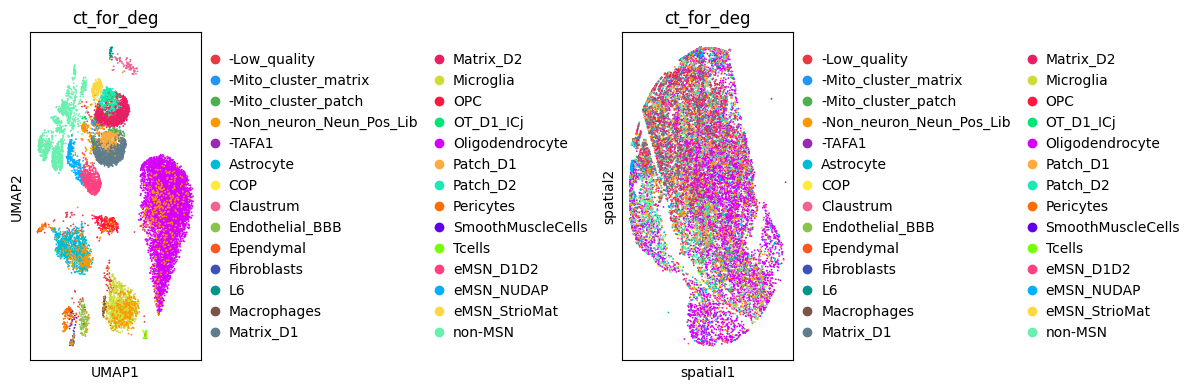

In [30]:
# Select a single slice
mask_slice = adata.obsm["spatial"][:, 0] > sample_infos[SAMPLE]["split_2_pucks_y"]  # example threshold
adata_slice = adata[mask_slice].copy()
lmu.plot_umap_spatial(adata_slice, color=["ct_for_deg"], name="", ncols=1)


... storing 'mp' as categorical


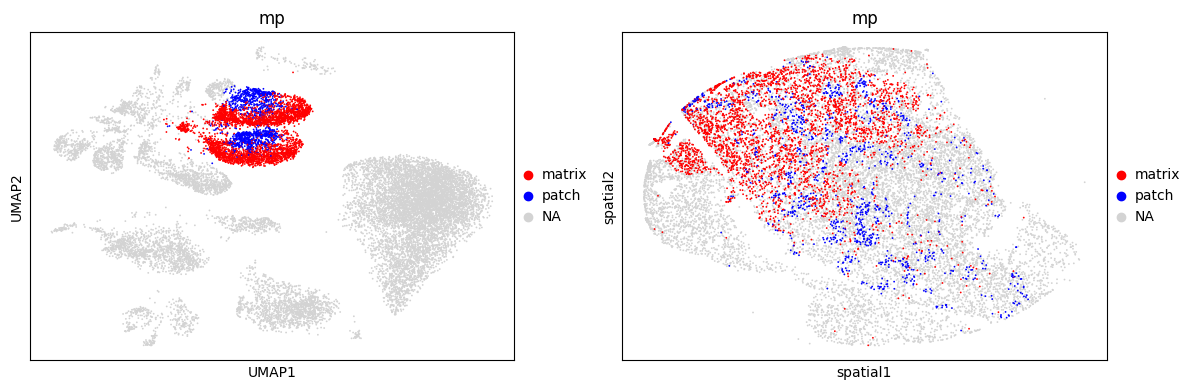

In [31]:
# add lbale to be tapch or amtrix
patch_matrix_map = {
    # Striosome (patch)
    "STRd D1 Striosome MSN": "patch",
    "STRd D2 Striosome MSN": "patch",
    
    # Matrix
    "STRd D1 Matrix MSN":    "matrix",
    "STRd D2 Matrix MSN":    "matrix",
    "STRv D1 MSN":           "matrix",
    "STRv D2 MSN":           "matrix",
}

# ise "Grpouo_name" so all cells et a label
adata_slice.obs["mp"] = adata_slice.obs["Group_name"].map(patch_matrix_map)
lmu.plot_umap_spatial(adata_slice, color=["mp"], name="", ncols=1, palette=["#FF0000", "#0000FF"], groups=["patch", "matrix"])

### Define dead region (based on no-more matrix)

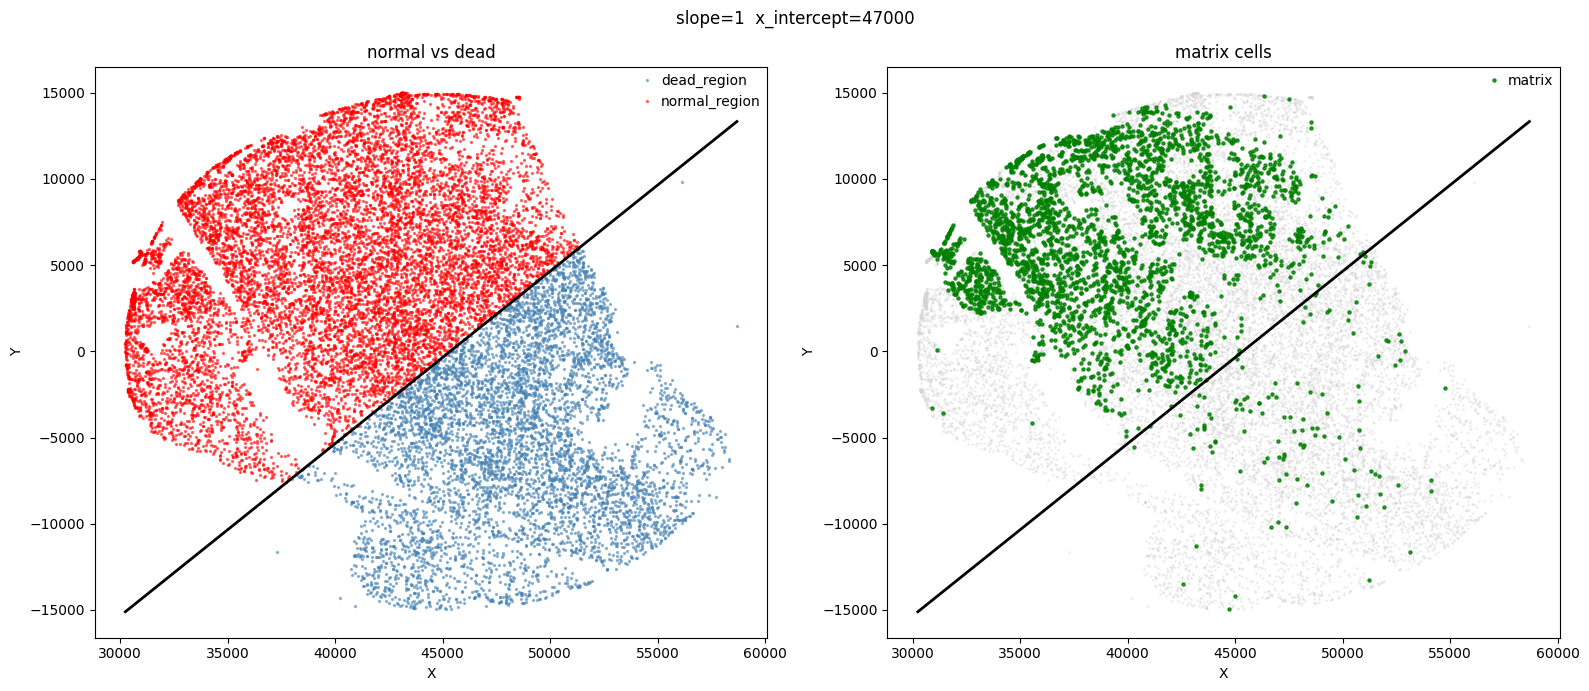

... storing 'spatial_region' as categorical


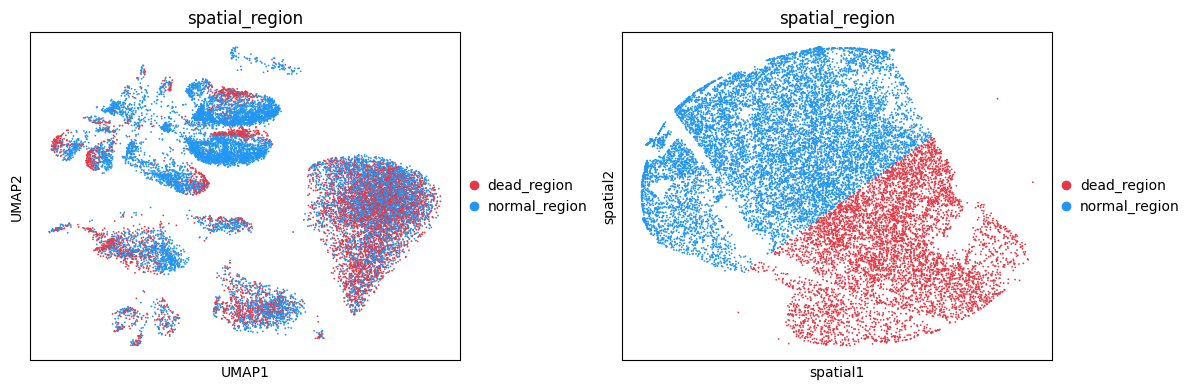

In [32]:
# ── Tweak these and rerun ───────────────────────────────────────────────────
slope        =  sample_infos[SAMPLE]["slope_line"]
x_intercept  = sample_infos[SAMPLE]["intercept_line"]
flip_dead    = sample_infos[SAMPLE]["flip_dead"]


# ── Compute ──────────────────────────────────────────────────────────────────
coords = adata_slice.obsm["spatial"]
valid  = ~np.isnan(coords).any(axis=1)
valid_coords = coords[valid]
mask_matrix  = (adata_slice.obs["mp"] == "matrix").values[valid]

y_mean = valid_coords[:, 1].mean()
normal = np.array([-slope, 1])
ref    = np.array([x_intercept, y_mean])
side   = (valid_coords - ref) @ normal

# ── Apply ────────────────────────────────────────────────────────────────────
side_all = np.full(len(coords), np.nan)
side_all[valid] = side
adata_slice.obs["spatial_region"] = "unassigned"
adata_slice.obs.loc[valid, "spatial_region"] = np.where(
    side > 0,
    "dead_region" if flip_dead else "normal_region",
    "normal_region" if flip_dead else "dead_region",
)

# ── Plot ─────────────────────────────────────────────────────────────────────
x_range = np.linspace(valid_coords[:, 0].min(), valid_coords[:, 0].max(), 200)
y_line  = slope * (x_range - x_intercept) + y_mean

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: normal vs dead
axes[0].scatter(valid_coords[side <= 0, 0], valid_coords[side <= 0, 1],
                c="steelblue", s=2, alpha=0.5, label="dead_region")
axes[0].scatter(valid_coords[side >  0, 0], valid_coords[side >  0, 1],
                c="red", s=2, alpha=0.5, label="normal_region")
axes[0].plot(x_range, y_line, "k-", linewidth=2)
axes[0].legend(); axes[0].set_xlabel("X"); axes[0].set_ylabel("Y")
axes[0].set_title("normal vs dead")

# Right: matrix cells only
axes[1].scatter(valid_coords[~mask_matrix, 0], valid_coords[~mask_matrix, 1],
                c="lightgray", s=1, alpha=0.3)
axes[1].scatter(valid_coords[mask_matrix, 0], valid_coords[mask_matrix, 1],
                c="green", s=5, alpha=0.8, label="matrix")
axes[1].plot(x_range, y_line, "k-", linewidth=2)
axes[1].legend(); axes[1].set_xlabel("X"); axes[1].set_ylabel("Y")
axes[1].set_title("matrix cells")

plt.suptitle(f"slope={slope}  x_intercept={x_intercept}")
plt.tight_layout()
plt.show()

lmu.plot_umap_spatial(adata_slice, color=["spatial_region"], name="", ncols=1)

### Se if hihg mit cluste sits in same region

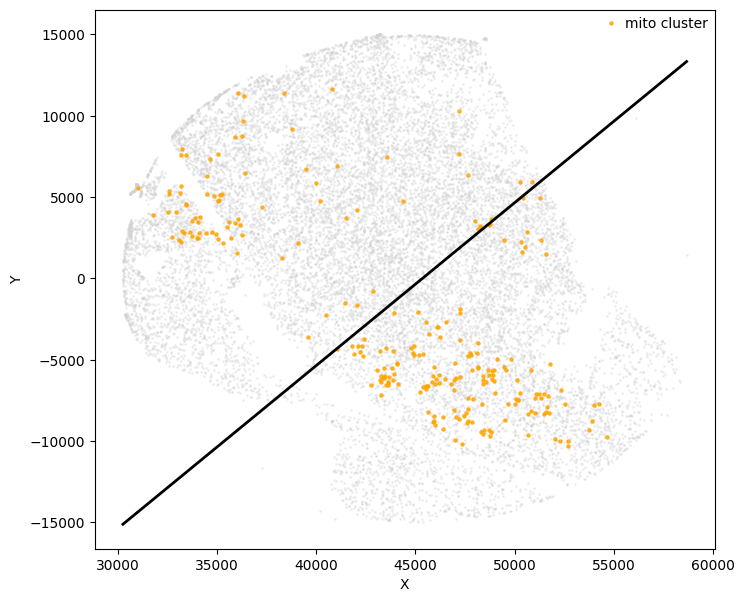

In [33]:
mask_mito = (adata_slice.obs["ct_for_deg"] == "-Mito_cluster_patch").values[valid]

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(valid_coords[~mask_mito, 0], valid_coords[~mask_mito, 1], c="lightgray", s=1, alpha=0.3)
ax.scatter(valid_coords[mask_mito,  0], valid_coords[mask_mito,  1], c="orange",    s=5, alpha=0.8, label="mito cluster")
ax.plot(x_range, y_line, "k-", linewidth=2)
ax.legend(); ax.set_xlabel("X"); ax.set_ylabel("Y")
plt.show()

### cells all around dying pathces

... storing 'in_mito_hull' as categorical


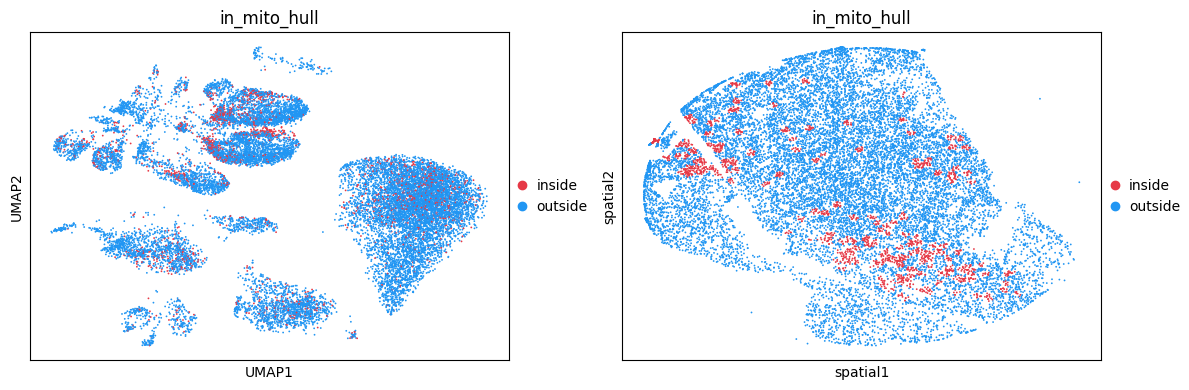

In [34]:
from shapely.geometry import Point, MultiPolygon
from shapely.ops import unary_union
from matplotlib.patches import PathPatch
from matplotlib.path import Path
import numpy as np

# ── Parameters ────────────────────────────────────────────────────────────────
RADIUS = 300  # tweak this — same units as your spatial coords

# ── Get mito coords ───────────────────────────────────────────────────────────
mask_mito = (adata_slice.obs["ct_for_deg"] == "-Mito_cluster_patch").values[valid]
mito_coords = valid_coords[mask_mito]

# ── Buffer each cell and merge all circles ────────────────────────────────────
circles = [Point(x, y).buffer(RADIUS) for x, y in mito_coords]
merged  = unary_union(circles)  # single merged polygon (or MultiPolygon if clusters are far apart)

# ── Label inside / outside ────────────────────────────────────────────────────
inside_all = np.full(len(coords), False)
inside_all[valid] = np.array([merged.contains(Point(x, y)) for x, y in valid_coords])
adata_slice.obs["in_mito_hull"] = "outside"
adata_slice.obs.loc[valid, "in_mito_hull"] = np.where(
    inside_all[valid], "inside", "outside"
)

# ── Helper to draw merged shape on a matplotlib ax ───────────────────────────
def draw_merged_shape(ax, shape, **kwargs):
    defaults = dict(facecolor="orange", alpha=0.15, edgecolor="orange",
                    linewidth=1.5, linestyle="--", zorder=4)
    defaults.update(kwargs)

    # handle both Polygon and MultiPolygon
    polys = shape.geoms if isinstance(shape, MultiPolygon) else [shape]
    for poly in polys:
        x, y = poly.exterior.xy
        coords_ring = np.column_stack([x, y])
        path  = Path(coords_ring)
        patch = PathPatch(path, **defaults)
        ax.add_patch(patch)

draw_merged_shape(axes[0], merged)
draw_merged_shape(axes[1], merged)

lmu.plot_umap_spatial(adata_slice, color=["in_mito_hull"], name="", ncols=1)

... storing 'ct_in_mito_hull' as categorical


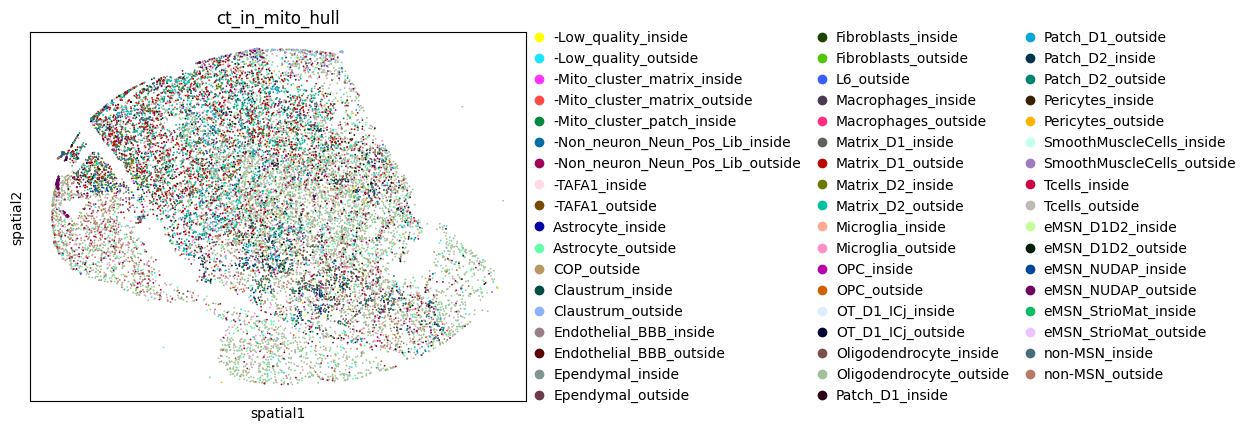

In [35]:
# define cell type if it in in the rousou or not
adata_slice.obs["ct_in_mito_hull"] = (
    adata_slice.obs["ct_for_deg"].astype(str)
    + "_"
    + adata_slice.obs["in_mito_hull"].astype(str)
)
sc.pl.embedding(adata_slice, basis="spatial", color=["ct_in_mito_hull"], ncols=1)

### Gene marker each combianton

- single slice

combination = (ct x zone x is_dead_region x is_mito)

In [36]:
# GENE_SYMBOL_COL = "gene_symbol"  # adjust to your adata.var column name
# N_GENES = 5 # number marker gene to plot
# MIN_CELLS = 3 # min numebr of cell in a comaniton to run DEG

# ZONE_CT_MAP = {
#     "Matrix_D1": "zone",
#     "Matrix_D2": "zone",
#     "Patch_D1":  "zone_4",
#     "Patch_D2":  "zone_4",
# }

# LABEL_COL = "ct_for_deg_no_mito"

# # ── 1. Build combined label ──────────────────────────────────────────────────
# adata_slice.obs["combined"] = "unassigned"

# for ct, zone_var in ZONE_CT_MAP.items():
#     mask    = adata_slice.obs[LABEL_COL] == ct
#     zone    = adata_slice.obs.loc[mask, zone_var].astype(str)
#     is_dead = adata_slice.obs.loc[mask, "spatial_region"].astype(str)
#     is_mito = (adata_slice.obs.loc[mask, "ct_for_deg"] == "-Mito_cluster_patch").astype(str)
#     adata_slice.obs.loc[mask, "combined"] = ct + "_" + zone + "_" + is_dead + "_is_mito_" + is_mito


# adata_slice.obs["combined"] = adata_slice.obs["combined"].astype("category")
# display(adata_slice.obs["combined"].value_counts())

# # ── 2. Drop small groups & run DEG once on all data ─────────────────────────
# counts = adata_slice.obs["combined"].value_counts()
# valid  = counts[counts >= MIN_CELLS].index
# adata_deg = adata_slice[adata_slice.obs["combined"].isin(valid)].copy()
# adata_deg.obs["combined"] = adata_deg.obs["combined"].cat.remove_unused_categories()

# ct_col = "combined"


# # run DEG per cell type
# for ct in ZONE_CT_MAP:

#     # lect only current cell type
#     mask = adata_deg.obs["combined"].str.startswith(ct + "_")
#     adata_deg_sub = adata_deg[mask].copy()  
#     sc.pl.embedding(adata_deg_sub, basis="spatial", color="combined", size=100, palette=lmu.custom_palette, title=f"{ct} | combined label")

#     # adata_deg_sub = sc.pp.scale(adata_deg_sub, layer="log1p_norm", zero_center=True, max_value=10, copy=True)
#     # adata_deg_sub.layers["scaled"] = adata_deg_sub.X.copy()  # store scaled values in a new layer

#     df, key_unfiltered_for_plotting, genes_overcame_filtering = deg_wilcoxon(
#             adata_deg_sub,
#             group_col=ct_col,
#             #groups_to_select=["-Mito_cluster_patch"], 
#             gene_symbol_col="gene_symbol",
#             layer = "log1p_norm",

#             # just want to be consistent in this gorup
#             min_in_group_fraction=0, 
#             max_out_group_fraction=1,

#             min_fold_change=0.5,
#             only_upregulated=False
#     )

#     N_GENES_TO_PLOT = 30
#     genes_overcame_filtering = genes_overcame_filtering[:N_GENES_TO_PLOT]

#     sc.pl.rank_genes_groups_dotplot(
#         adata_deg_sub, #
#         #groups=["-Mito_cluster_patch"], #which group's top genes appear as columns
#             #  rows always show every group present in the groupby column of adata_sub
#         n_genes=5, #How many top genes to show PER GROUP
#         key=key_unfiltered_for_plotting, # ATTENTION: use unfiltered results for plotting, otherwise many genes will be NaN
#         #var_names=genes_overcame_filtering, # only show genes that overcame filtering
#         values_to_plot="logfoldchanges",  # color = logFC instead of expression
#             # None              → mean expression
#             #"scores"          → Wilcoxon U statistic
#             # logfoldchanges
#             # ---< Dot size always = fraction of cells expressing the gene 
#         cmap="bwr",
#         vmin=-4, vmax=4,
#         colorbar_title="log2 FC",
#         use_raw=False,
#         layer="log1p_norm",
#     )

#     sc.pl.rank_genes_groups_matrixplot(
#         adata_deg_sub,
#         #groups=["-Mito_cluster_patch"],  # which group's top genes to show as columns
#         n_genes=5,                       # top 20 genes
#         key=key_unfiltered_for_plotting,
#         values_to_plot="logfoldchanges",  # color = logFC
#         cmap="bwr",                       # blue=down, red=up
#         vmin=-4, vmax=4,
#         colorbar_title="log2 FC",
#         use_raw=False,
#         layer="log1p_norm",
#         show=True,
#         #var_names=genes_overcame_filtering, # only show genes that overcame filtering
#     )


#     display(df.head(20))
#     print(f"Number of DEs: {df.shape[0]}")

### Coccurnce

- single slcie
- only dead region

/home/gdallagl/myworkdir/XDP/utils/label_mapping_utils.py:237: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


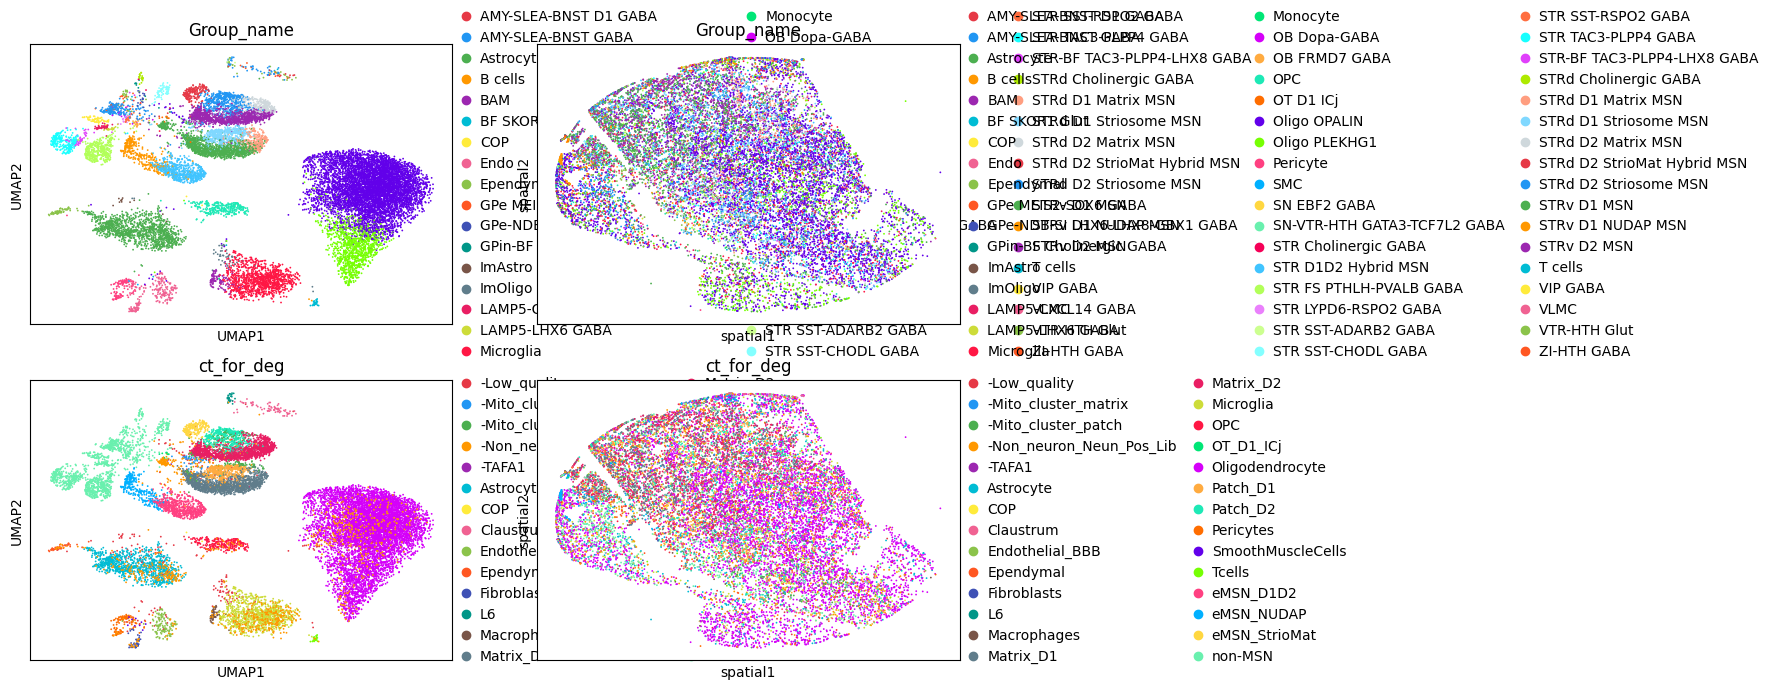

Kept 17939 / 17939 cells after spatial NaN filter


... storing 'ct_for_deg_co_occurrence' as categorical


ct_for_deg
Patch_D1               183
-Mito_cluster_patch    166
Patch_D2               136
Matrix_D2               30
Matrix_D1               28
Name: count, dtype: int64


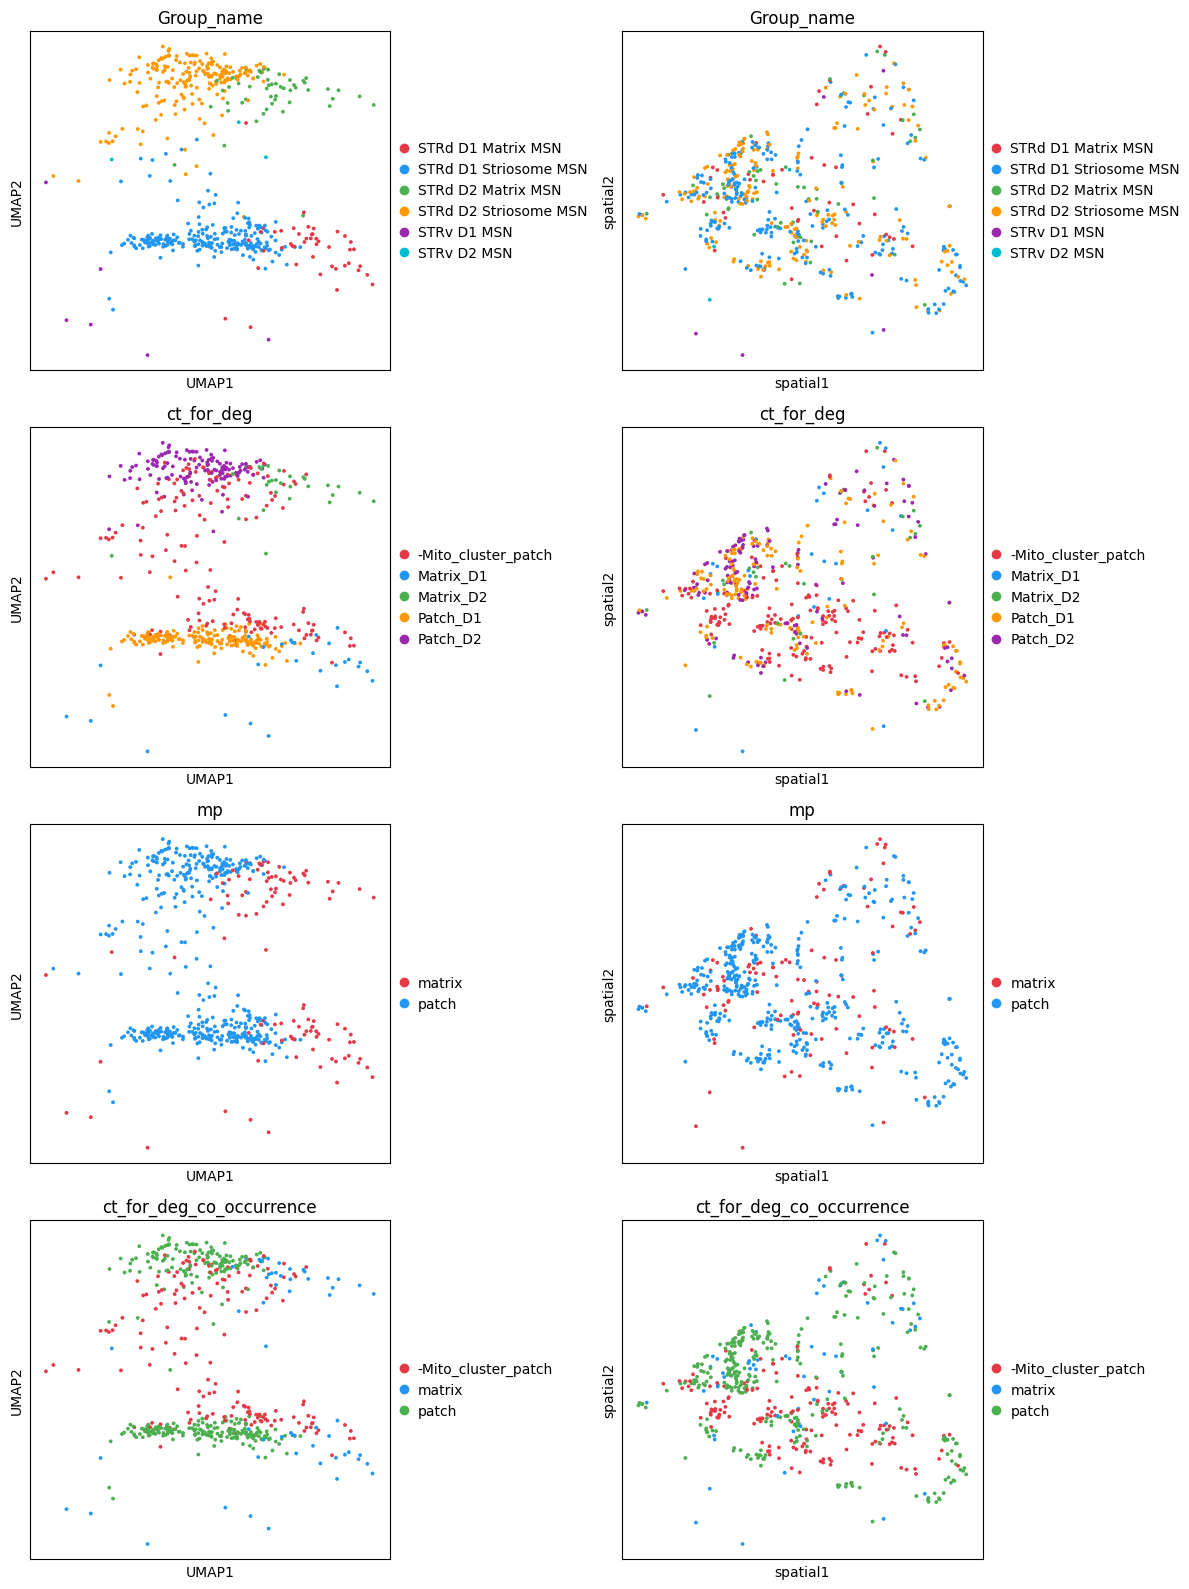

ERROR: Unable to fetch palette, reason: 'ct_for_deg_co_occurrence_colors'. Using `None`.
ERROR: Unable to fetch palette, reason: 'ct_for_deg_co_occurrence_colors'. Using `None`.
ERROR: Unable to fetch palette, reason: 'ct_for_deg_co_occurrence_colors'. Using `None`.


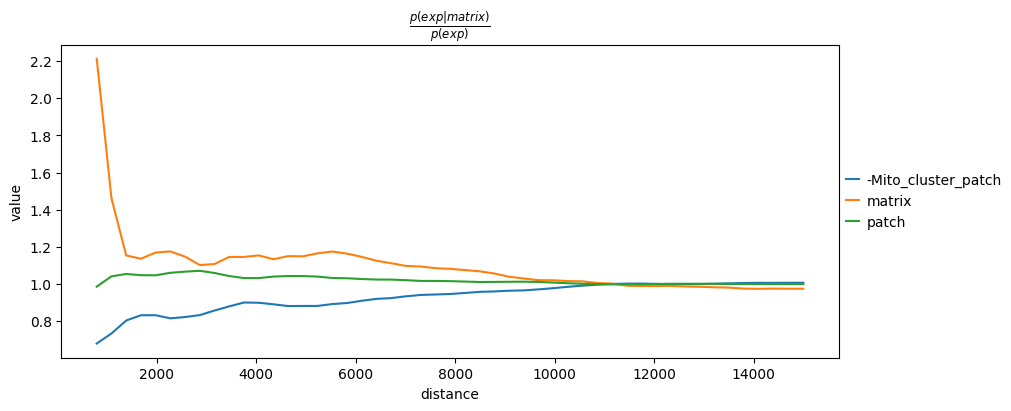

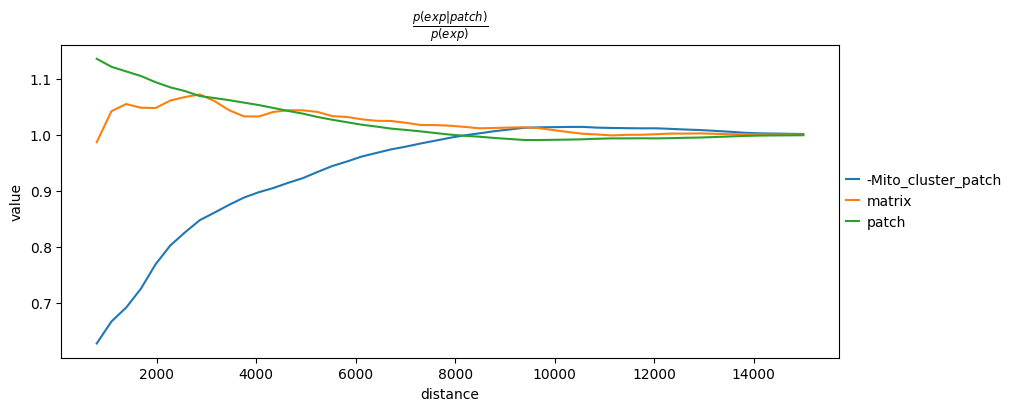

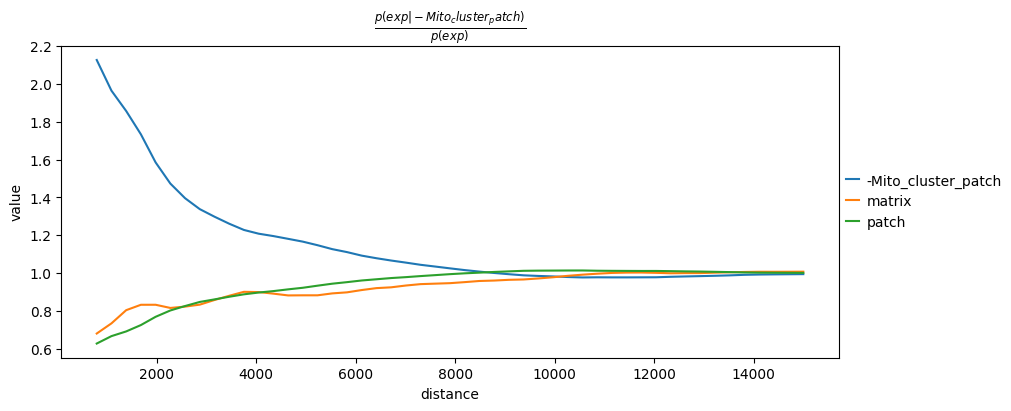

In [37]:
import squidpy as sq

# ATTNETION USING SINGLE SLICE
# ATTENTION USING ONYL DEAD ZONE
# ATTENTION DO NOT CHANGE BETWEEN D1 AND D2 VERSIONS (JUT USE MATRIX AND AAPTCH)

lmu.plot_umap_spatial(adata_slice, color=["Group_name", "ct_for_deg"], name="", ncols=1)

# ── 2. Remove NaN spatial coordinates ──────────────────────────────────────
mask_valid = ~np.isnan(adata_slice.obsm["spatial"]).any(axis=1)
adata_sq = adata_slice[mask_valid].copy()
print(f"Kept {mask_valid.sum()} / {len(mask_valid)} cells after spatial NaN filter")

# ──  ────────────────────────────────────
# Select cell type
adata_sq = adata_sq[adata_sq.obs["ct_for_deg"].isin(["Patch_D1", "Patch_D2", "-Mito_cluster_patch", "Matrix_D1", "Matrix_D2"])].copy()  
# sect dead region
adata_sq = adata_sq[adata_sq.obs["spatial_region"] == "dead_region"].copy()
# remove low waulity
mask_low_q = adata_sq.obs["ct_for_deg"].str.startswith("-") & (adata_sq.obs["ct_for_deg"] != "-Mito_cluster_patch")

adata_sq.obs["ct_for_deg"] = adata_sq.obs["ct_for_deg"].cat.remove_unused_categories()
print(adata_sq.obs["ct_for_deg"].value_counts())
adata_sq = adata_sq[~mask_low_q].copy()

# define col for coorcune
adata_sq.obs["ct_for_deg_co_occurrence"] = adata_sq.obs["mp"].astype(str)
adata_sq.obs.loc[adata_sq.obs["ct_for_deg"].isin(["-Mito_cluster_patch"]),"ct_for_deg_co_occurrence"] = "-Mito_cluster_patch"

# ── 4. Plot UMAP + spatial of the subset ───────────────────────────────────
lmu.plot_umap_spatial(adata_sq, color=["Group_name", "ct_for_deg", "mp", "ct_for_deg_co_occurrence"], name="", ncols=1, size=30)

# ── 5. Run co-occurrence ────────────────────────────────────────────────────

# Delete previos run
if "ct_for_deg_co_occurrence_co_occurrence" in adata_sq.uns:
    del adata_sq.uns["ct_for_deg_co_occurrence_co_occurrence"]

# Recompute with correct interval
"""
 For each pair of cell types and each distance bin d, it calculates how much more (or less) likely you are to find cell type B within distance d of cell type A 
 compared to a random spatial distribution.
"""
sq.gr.co_occurrence(
    adata_sq,
    cluster_key="ct_for_deg_co_occurrence",
    interval=np.linspace(500, 15000, 50),
)

# let him choos the colrs
adata_sq.uns.pop("ct_for_deg_co_occurrence_colors", None)

# Plot
for c in ["matrix", "patch", "-Mito_cluster_patch"]:
    sq.pl.co_occurrence(
        adata_sq,
        cluster_key="ct_for_deg_co_occurrence",
        clusters=[c],
        figsize=(10, 4),
        #ncols=1
    )


# DEG (wilconx) within dead zone between Mito_cluster_patch other cell types

see DEG gens betteen dying cells (mito high) and all ohter healhty cells (still in dead region)

- single slice
- only in dead region
- no D1 D2 distirnciton

... storing 'ct_for_deg_mpm' as categorical


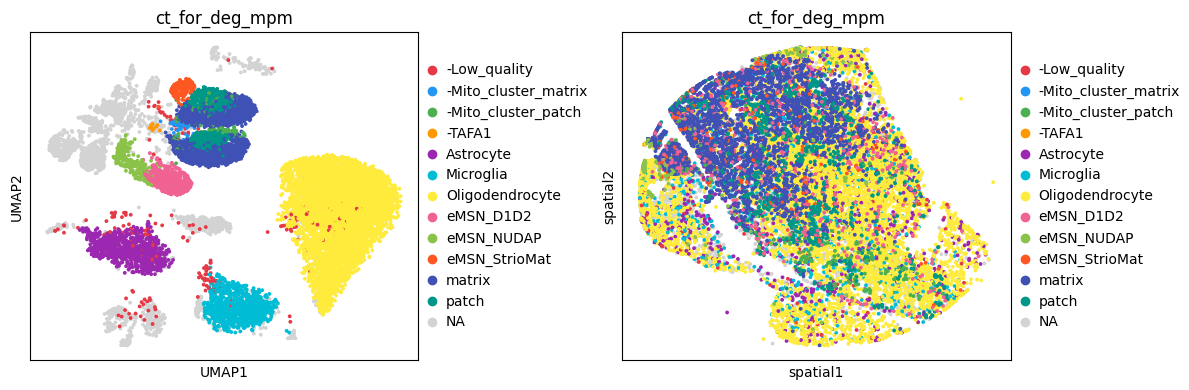

In [38]:
# define col for cell type
    # matrix, patch, mito cluster (no D1 D2)

dict_mapping = {
    "Matrix_D1": "matrix",
    "Matrix_D2": "matrix",

    "Patch_D1":  "patch",
    "Patch_D2":  "patch",

    "-Mito_cluster_patch": "-Mito_cluster_patch",
    "-Mito_cluster_matrix": "-Mito_cluster_matrix",
    LOW_QUALITY_LABEL: LOW_QUALITY_LABEL,

    "eMSN_D1D2": "eMSN_D1D2",
    "eMSN_StrioMat": "eMSN_StrioMat",
    "eMSN_NUDAP": "eMSN_NUDAP",
    "-TAFA1": "-TAFA1",

    "Microglia": "Microglia",
    "Oligodendrocyte": "Oligodendrocyte",
    "Astrocyte": "Astrocyte",
}
adata_slice.obs["ct_for_deg_mpm"] = adata_slice.obs["ct_for_deg"].map(dict_mapping)

lmu.plot_umap_spatial(adata_slice, color=["ct_for_deg_mpm"], name="", ncols=1, size=30, palette=preprocessing.custom_palette)


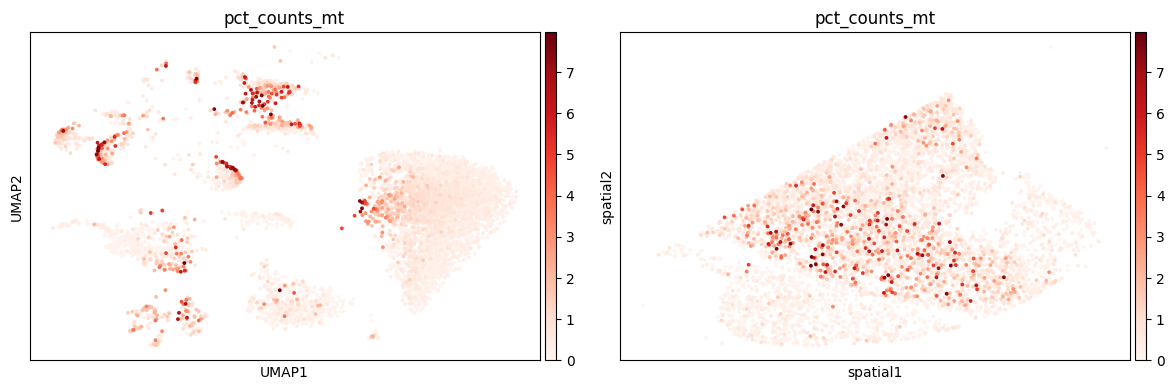

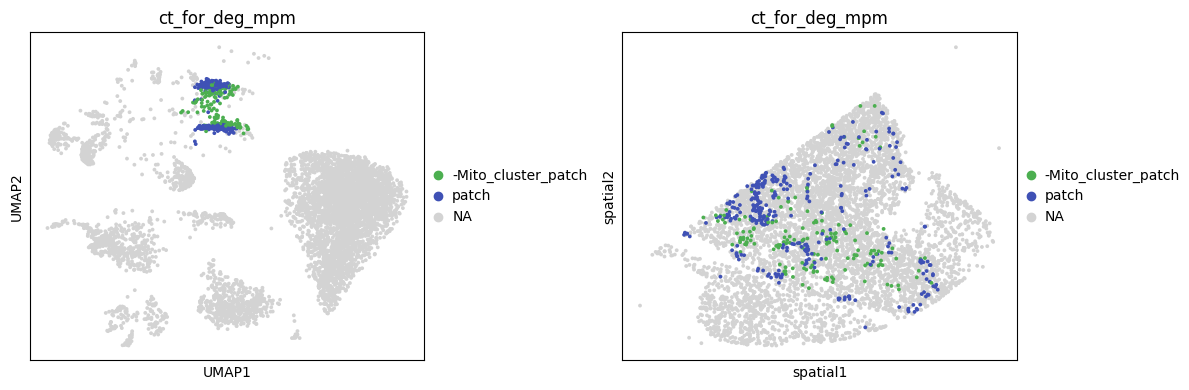

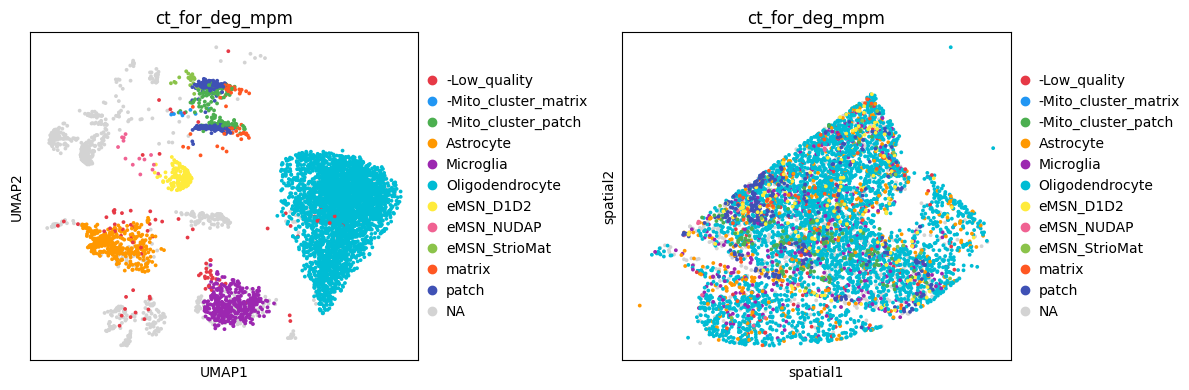

In [39]:
# # Select only path cells and Mito_cluster_poathc
# adata_slice_patch = adata_slice[adata_slice.obs["ct_for_deg_mpm"].isin(["patch", "-Mito_cluster_patch"])].copy()

# slect only cells on dead region
adata_slice_dead = adata_slice[adata_slice.obs["spatial_region"] == "dead_region"].copy()

lmu.plot_umap_spatial(adata_slice_dead, color=["pct_counts_mt"], name="", ncols=1, size=30, cmap="Reds")
lmu.plot_umap_spatial(adata_slice_dead, color=["ct_for_deg_mpm"], groups=["-Mito_cluster_patch", "patch"],name="", ncols=1, size=30, palette=preprocessing.custom_palette)
lmu.plot_umap_spatial(adata_slice_dead, color=["ct_for_deg_mpm"],name="", ncols=1, size=30, palette=preprocessing.custom_palette)

In [40]:
def deg_wilcoxon(
        adata_sub,
        group_col,
        gene_symbol_col="gene_symbol",
        layer = "log1p_norm",
        groups=None,
        min_in_group_fraction=0.25,
        max_out_group_fraction=0.5,
        min_fold_change=1,
        only_upregulated=False,
        n_genes_per_group=10,
        reference="rest",
):
    
    if only_upregulated:
        rankby_abs = False  # rank by raw score → upregulated genes rank highest
        compare_abs = False # fold-change filter is directional (positive only)
        order_by = "logfoldchanges"
    else:
        rankby_abs = True   # rank by |score| → both up & down surface equally
        compare_abs = True  # fold-change filter applies to |logFC|
        order_by = "scores"  # order by raw score, not logFC, to get top mixed genes

    # set index
    adata_sub.var.index = adata_sub.var[gene_symbol_col].astype(str)  # drop Categorical
    adata_sub.var_names_make_unique()

    # Calcuclate deg
    sc.tl.rank_genes_groups(
        adata_sub,
        mask_var=None,        # no masking, use all genes 
        groupby=group_col,       # which obs column defines the groups
        groups=groups,  # which groups to test (default: all)
        n_genes=adata_sub.shape[1], # saves scores for every single gene, not just the top N.
        reference=reference, # What to compare each group AGAINST, Use a specific group name for pairwise comparison
        method="wilcoxon",    # statistical test
        use_raw=False,        # ALYAS explicti say use adata.X, not adata.raw.X
        layer=layer,    # use this specific layer as input
        rankby_abs=rankby_abs,       # True  → rank by |score| (up AND downregulated, mixed)
        pts=True,       # (pct expressed in group, pct expressed in rest)
        key_added="rank_genes_groups" # store results in this key in adata.uns
    )
    # Filter deg
    sc.tl.filter_rank_genes_groups(
        adata_sub,
        key="rank_genes_groups", # which result to filter (the one before)
        key_added="rank_genes_groups_filtered", # store filtered results here
        min_in_group_fraction=min_in_group_fraction,
        max_out_group_fraction=max_out_group_fraction,
        min_fold_change=min_fold_change,
        compare_abs=compare_abs # True  → min_fold_change applies to |logFC|, both up AND downregulated genes can pass
    ) 
    
    #ATTENTION When filter_rank_genes_groups rejects a gene, it replaces its name with NaN but keeps the statistics

    # AFTER (correct - pull from adata_sub.uns populated by sc.tl.rank_genes_groups)
    df = sc.get.rank_genes_groups_df(
        adata_sub, 
        group=groups[0] if groups and len(groups) == 1 else None,  # explicit group if only one
        key="rank_genes_groups_filtered",#_filtered", #ATTNETION
        pval_cutoff=0.05,       # filters by adjusted p-value
        log2fc_min=None,        
        log2fc_max=None,
        gene_symbols=gene_symbol_col
    )

    # if only one group was tested, scanpy drops the "group" column — add it back
    if "group" not in df.columns:
        df["group"] = groups[0]

    # REMOVE FILTERED GENES
    df = df[df["names"].notna() & (df["names"] != "nan")]

    # dict with top genes per group for plotting
        # top gene by ...

    genes_per_group = (
        df.assign(abs_score=df["scores"].abs())
        .sort_values("abs_score", ascending=False)
        .groupby("group")["names"]
        .apply(lambda x: x.head(n_genes_per_group).tolist())
        .to_dict()
    )
    display(genes_per_group)
  
    return df, "rank_genes_groups", genes_per_group

In [41]:
# # DEG
#     # mito cluster Vs otehr cell types )in single slice, in dead region)
#     # want to know what makes it special compared to each other cell type individually

# # col iht the cell types
# ct_col = "ct_for_deg_mpm"

# # cell type to compore agains /this is the stim constrast)
# mito_label = "-Mito_cluster_patch" 

# # all other cell type to use as baseline (not Mito and not nan cell types and not low quality (start with "-")
# other_groups = [
#     g for g in adata_slice_dead.obs[ct_col].unique()
#     if g != mito_label and pd.notna(g) and not str(g).startswith("-")  # exclude low quality clusters
# ]

# results = {}

# for other_ct in other_groups:

#     print(f"\nComparing {mito_label} vs {other_ct}")

#     adata_tmp = adata_slice_dead.copy()
    
#     df, _, genes = deg_wilcoxon(
#         adata_tmp,        # copy so uns isn't overwritten each iter
#         group_col=ct_col,
#         gene_symbol_col="gene_symbol",
#         layer="log1p_norm", 
#         groups=[mito_label],  # test only this group against the reference
#         reference=other_ct,             # mito vs THIS specific type --< mito is the contrast (not baseline)
#         min_in_group_fraction=0.5,
#         max_out_group_fraction=1, # ATTENTION: no filter here, dont care if a gene si also expressed in the otehr cell type
#         only_upregulated=False,
#         n_genes_per_group=30, # numebr genes to plot
#     )

#     # keep only mito cluster rows — that's the group we care about
#     df_mito = df[df["group"] == mito_label].copy()
#     results[other_ct] = {
#         "df": df_mito,
#         "top_genes": genes.get(mito_label, []),
#         "uns_key":   adata_tmp.uns["rank_genes_groups"],   # <-- save this
#         "var_names": adata_tmp.var_names,                   # <-- var index after renaming
#     }

# results
# # final_df = pd.concat(df_list, ignore_index=True)
# # final_df.to_csv(f"/home/gdallagl/myworkdir/XDP/data/XDP/diseased/{SAMPLE}/adata/DEGs_in_mito_cluster_patch_vs_normal_in_dead_region.csv", index=False)
# # final_df



In [42]:
# for other_ct, res in results.items():
#     if not res["top_genes"]:
#         continue

#     mask = adata_slice_dead.obs[ct_col].isin([mito_label, other_ct])
#     adata_pair = adata_slice_dead[mask].copy()

#     # rename var index to gene symbols (same as deg_wilcoxon does)
#     adata_pair.var.index = adata_pair.var["gene_symbol"].astype(str)
#     adata_pair.var_names_make_unique()

#     # copy DEG results into adata_pair so rank_genes_groups_dotplot can read them
#     adata_pair.uns["rank_genes_groups"] = res["uns_key"]

#     sc.pl.rank_genes_groups_dotplot(
#         adata_pair,
#         var_names=res["top_genes"],    # show exactly these genes
#         key="rank_genes_groups",
#         values_to_plot="logfoldchanges",   # <-- logFC as color
#         cmap="bwr",
#         vmin=-3, vmax=3,
#         colorbar_title="log2 FC",
#         use_raw=False,
#         layer="log1p_norm",
#         title=f"Mito vs {other_ct}",
#         show=True,
#     )


In [43]:
# for other_ct, res in results.items():
    
#     if not res["top_genes"]:
#         continue

#     # subset to only the two cell types being compared
#     mask = adata_slice_dead.obs[ct_col].isin([mito_label, other_ct])
#     adata_pair = adata_slice_dead[mask].copy()

#     adata_pair.var.index = adata_pair.var["gene_symbol"].astype(str)  # drop Categorical
#     adata_pair.var_names_make_unique()

#     #sc.pl.dotplot always colors by mean expression
#     sc.pl.dotplot(
#         adata_pair,
#         var_names=res["top_genes"],
#         groupby=ct_col,
#         use_raw=False,
#         layer="log1p_norm",
#         standard_scale="var",
#         title=f"Mito vs {other_ct}",
#         show=True
#     )

In [69]:
patch_d1_bican = sc.read_h5ad(f"/home/gdallagl/myworkdir/XDP/data/STR_zonation_references_h5ad/STRd_D1_Striosome_MSN.h5ad")
print(patch_d1_bican)
patch_d2_bican = sc.read_h5ad(f"/home/gdallagl/myworkdir/XDP/data/STR_zonation_references_h5ad/STRd_D2_Striosome_MSN.h5ad")
print(patch_d2_bican)

patch_bican = patch_d1_bican.concatenate(patch_d2_bican, batch_key="original_batch", batch_categories=["D1_Striosome", "D2_Striosome"])
print(patch_bican)

AnnData object with n_obs × n_vars = 20903 × 37905
    obs: 'orig.ident', 'nCount_originalexp', 'nFeature_originalexp', 'PREFIX', 'CELL_BARCODE', 'NUM_GENIC_READS', 'NUM_TRANSCRIPTS', 'NUM_GENES', 'num_retained_transcripts', 'pct_coding', 'pct_utr', 'pct_intergenic', 'pct_genic', 'pct_intronic', 'pct_mt', 'pct_ribosomal', 'frac_contamination', 'experiment', 'donor_external_id', 'is_primary_data', 'Neighborhood_label', 'Neighborhood_name', 'Neighborhood_bootstrapping_probability', 'Class_label', 'Class_name', 'Class_bootstrapping_probability', 'Subclass_label', 'Subclass_name', 'Subclass_bootstrapping_probability', 'Group_label', 'Group_name', 'Group_bootstrapping_probability', 'Cluster_label', 'Cluster_name', 'Cluster_alias', 'Cluster_bootstrapping_probability', 'donor_id', 'n_counts', 'nCount_RNA', 'nFeature_RNA', 'x', 'y', 'RNA_snn_res.0.8', 'seurat_clusters', 'library', 'donor', 'x_um2', 'y_um2', 'unique_cell_ID', 'AK_celltype', 'RNA_snn_res.0.2', 'cb', 'clusters', 'num_dbscan', 'lo

/tmp/ipykernel_936199/3907235485.py:6: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  patch_bican = patch_d1_bican.concatenate(patch_d2_bican, batch_key="original_batch", batch_categories=["D1_Striosome", "D2_Striosome"])


AnnData object with n_obs × n_vars = 38033 × 37905
    obs: 'orig.ident', 'nCount_originalexp', 'nFeature_originalexp', 'PREFIX', 'CELL_BARCODE', 'NUM_GENIC_READS', 'NUM_TRANSCRIPTS', 'NUM_GENES', 'num_retained_transcripts', 'pct_coding', 'pct_utr', 'pct_intergenic', 'pct_genic', 'pct_intronic', 'pct_mt', 'pct_ribosomal', 'frac_contamination', 'experiment', 'donor_external_id', 'is_primary_data', 'Neighborhood_label', 'Neighborhood_name', 'Neighborhood_bootstrapping_probability', 'Class_label', 'Class_name', 'Class_bootstrapping_probability', 'Subclass_label', 'Subclass_name', 'Subclass_bootstrapping_probability', 'Group_label', 'Group_name', 'Group_bootstrapping_probability', 'Cluster_label', 'Cluster_name', 'Cluster_alias', 'Cluster_bootstrapping_probability', 'donor_id', 'n_counts', 'nCount_RNA', 'nFeature_RNA', 'x', 'y', 'RNA_snn_res.0.8', 'seurat_clusters', 'library', 'donor', 'x_um2', 'y_um2', 'unique_cell_ID', 'AK_celltype', 'RNA_snn_res.0.2', 'cb', 'clusters', 'num_dbscan', 'lo

In [72]:
# normluae
patch_bican.layers["counts"] = patch_bican.X.copy()  # store raw counts in a new layer
sc.pp.normalize_total(patch_bican, target_sum=1e4)
sc.pp.log1p(patch_bican)
patch_bican.layers["log1p_norm"] = patch_bican.X.copy()  # store log-normalized values in a new layer

# calcualre corre
mito_col = "pct_mt"

In [79]:
import pandas as pd
from scipy.stats import spearmanr

genes_of_interest = [
    'MT-CO1', 'MT-CO3', 'MT-CO2', 'MT-CYB', 'MT-ND4', 'MT-ATP6',
    'MT-ND1', 'MT-ND4L', 'MT-ND2', 'MT-ND3', 'MT-ND5',
    'ENSG00000289901', 'MEG3', 'GNG7', 'LINC00342', 'PNISR',
    'DST', 'ANKRD30BL', 'SRRM3', 'GPR149', 'ZNF91', 'CACNA1B',
    'ADAM22', 'SNHG14', 'PCNT', 'FOCAD', 'RUNX1T1', 'ABLIM2',
    'CDK17', 'DGKI'
]

# subset
patch_sub = patch_bican[:, patch_bican.var_names.isin(genes_of_interest)]

# inputs
mito = patch_sub.obs["pct_mt"].values
X = patch_sub.layers["log1p_norm"]
X = X.toarray() if hasattr(X, "toarray") else np.asarray(X)

# spearmanr for each gene vs pct_mt
results = []
for i, gene in enumerate(patch_sub.var_names):
    r, p = spearmanr(X[:, i], mito)
    results.append({"gene": gene, "correlation": r, "pval": p})

corrs = pd.DataFrame(results).set_index("gene").sort_values("correlation", ascending=False)
display(corrs)

,correlation,pval
gene,,
MT-CO1,0.867779,0.000000e+00
MT-CO2,0.833726,0.000000e+00
MT-CYB,0.812127,0.000000e+00
MT-CO3,0.809880,0.000000e+00
MT-ND2,0.805502,0.000000e+00
MT-ND5,0.799994,0.000000e+00
MT-ND4,0.784350,0.000000e+00
MT-ND4L,0.776032,0.000000e+00
MT-ND1,0.767388,0.000000e+00


In [82]:
patch_bican.var.index.to_list()

['A1BG',
 'A1BG-AS1',
 'A1CF',
 'A2M',
 'A2M-AS1',
 'A2ML1',
 'A2ML1-AS1',
 'A2ML1-AS2',
 'A2MP1',
 'A3GALT2',
 'A4GALT',
 'A4GNT',
 'AA06',
 'AAAS',
 'AACS',
 'AACSP1',
 'AADAC',
 'AADACL2',
 'AADACL2-AS1',
 'AADACL3',
 'AADACL4',
 'AADACP1',
 'AADAT',
 'AAGAB',
 'AAK1',
 'AAMDC',
 'AAMP',
 'AANAT',
 'AAR2',
 'AARD',
 'AARS1',
 'AARS2',
 'AARSD1',
 'AASDH',
 'AASDHPPT',
 'AASS',
 'AATBC',
 'AATF',
 'AATK',
 'ABALON',
 'ABAT',
 'ABCA1',
 'ABCA10',
 'ABCA12',
 'ABCA13',
 'ABCA2',
 'ABCA3',
 'ABCA4',
 'ABCA5',
 'ABCA6',
 'ABCA7',
 'ABCA8',
 'ABCA9',
 'ABCA9-AS1',
 'ABCB1',
 'ABCB10',
 'ABCB11',
 'ABCB4',
 'ABCB5',
 'ABCB6',
 'ABCB7',
 'ABCB8',
 'ABCB9',
 'ABCC1',
 'ABCC10',
 'ABCC11',
 'ABCC12',
 'ABCC13',
 'ABCC2',
 'ABCC3',
 'ABCC4',
 'ABCC5',
 'ABCC5-AS1',
 'ABCC6',
 'ABCC6P1',
 'ABCC6P2',
 'ABCC8',
 'ABCC9',
 'ABCD1',
 'ABCD2',
 'ABCD3',
 'ABCD4',
 'ABCE1',
 'ABCF1',
 'ABCF2',
 'ABCF3',
 'ABCG1',
 'ABCG2',
 'ABCG4',
 'ABCG5',
 'ABCG8',
 'ABHD1',
 'ABHD10',
 'ABHD11',
 'ABHD12',
 'ABH

In [84]:
import numpy as np
import pandas as pd

def fast_spearman_vs_vector(X, y):
    """Vectorized Spearman correlation of each column in X against vector y."""
    n = X.shape[0]

    # rank y
    y_r = np.argsort(np.argsort(y)).astype(np.float32)

    # rank all genes at once via double-argsort (vectorized, no Python loop)
    X_r = np.argsort(np.argsort(X, axis=0), axis=0).astype(np.float32)

    # center
    y_r -= y_r.mean()
    X_r -= X_r.mean(axis=0)

    # normalize
    y_r /= np.linalg.norm(y_r)
    X_r /= np.linalg.norm(X_r, axis=0)

    return X_r.T @ y_r

# densify
X = patch_bican.layers["log1p_norm"]
X = X.toarray() if hasattr(X, "toarray") else np.asarray(X)
X = X.astype(np.float32)

mito = patch_bican.obs["pct_mt"].values.astype(np.float32)

corrs = fast_spearman_vs_vector(X, mito)

corrs = pd.DataFrame(corrs, index=patch_bican.var_names, columns=["correlation"]) \
          .sort_values("correlation", ascending=False)
display(corrs)

,correlation
MT-CO1,0.867631
MT-CO2,0.833640
MT-CYB,0.811802
MT-CO3,0.809761
MT-ND2,0.804960
...,...
ADGRL3,-0.278594
LERFS,-0.302207
KDM5D,-0.305752
DENND1B,-0.308857


In [91]:
corrs.loc["MEG3"]

correlation    0.110793
Name: MEG3, dtype: float32

In [95]:
high_mito_cor_genes = corrs[corrs["correlation"] > 0.2].index.to_list()

high_mito_cor_genes = [c for c in high_mito_cor_genes if not c.startswith("ENSG")]  
high_mito_cor_genes

['MT-CO1',
 'MT-CO2',
 'MT-CYB',
 'MT-CO3',
 'MT-ND2',
 'MT-ND5',
 'MT-ND4',
 'MT-ND4L',
 'MT-ND1',
 'MT-ATP6',
 'MT-ATP8',
 'MT-ND3',
 'DHFR',
 'GRIN1',
 'MAP1A',
 'SRRM2',
 'ANKRD11',
 'APPAT',
 'PHYHIP',
 'NCDN',
 'MT-ND6',
 'LINC00342',
 'GOLGB1',
 'BPTF',
 'CACNA1B',
 'FAIM2',
 'AKAP9',
 'KIF1A',
 'BDP1',
 'PCNT',
 'MPHOSPH8',
 'SPTBN4',
 'SRRM3',
 'BMS1P14',
 'ABR',
 'ELAVL3',
 'GCC2',
 'FAM90A23',
 'GIMD1',
 'IFITM5',
 'IGHV1-18',
 'IGHV1OR21-1',
 'FOXA2',
 'F8A2',
 'POTEB2',
 'IGKV2D-26',
 'IGLV3-12',
 'IGLV3-13',
 'FTMT',
 'FRG2KP',
 'KRTAP13-2',
 'KRT85',
 'IL36A',
 'FOXI1',
 'FOXD3',
 'BECN2',
 'IGKV1D-17',
 'GH1',
 'GCG',
 'REG1B',
 'IGKV1-17',
 'IGKV1-22',
 'IGLV3-19',
 'IGLCOR22-1',
 'IGKV6-21',
 'IGKV3OR22-2',
 'IGKV2D-24',
 'IGKV2-30',
 'IGHV3OR16-7',
 'IGHV3-43',
 'IGHV3-30',
 'MAGEB4',
 'LINC02903',
 'LINC02784',
 'LINC02349',
 'LINC00424',
 'LGALS7',
 'H3C8',
 'HOXA11',
 'OR10W1',
 'HOXD10',
 'IGHV5-51',
 'IGHV3-66',
 'IGHV3-53',
 'HOXB13',
 'HOXA4',
 'HOXA2',
 'HOXA

<Axes: ylabel='Frequency'>

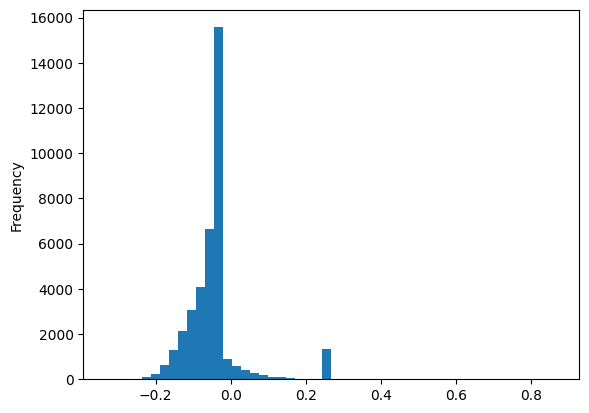

In [87]:
corrs["correlation"].plot(kind="hist", bins=50)


Comparing -Mito_cluster_patch vs Astrocyte


... storing 'ct_for_deg_mpm x library' as categorical
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:912: RuntimeWarning: overflow encountered in expm1
  (expm1_func(mean_in_cluster) + 1e-9)


{'-Mito_cluster_patch': ['MEG3',
  'LRRC7',
  'SLC35F3',
  'DLGAP2',
  'ADCY5',
  'PHACTR1',
  'SNTG1',
  'SORBS2',
  'RYR2',
  'RBFOX1',
  'FGF14',
  'NRXN3',
  'MACROD2',
  'KCNIP4',
  'CSMD1',
  'SNHG14',
  'ANK3',
  'DTNA',
  'DGKB',
  'DIRC3-AS1',
  'PDE10A',
  'CACNA1B',
  'KCNQ5',
  'GNAL',
  'SRRM3',
  'GRIN1',
  'SPOCK3',
  'RIMS2',
  'MYT1L',
  'QKI']}

,names,scores,logfoldchanges,pvals,pvals_adj,gene_symbol,pct_nz_group,group
0,SLC35F3,18.777777,35.482201,1.147870e-78,1.160195e-74,SLC35F3,1.000000,-Mito_cluster_patch
1,LRRC7,18.777777,12.503551,1.147870e-78,1.160195e-74,LRRC7,1.000000,-Mito_cluster_patch
2,MEG3,18.777777,36.240158,1.147870e-78,1.160195e-74,MEG3,1.000000,-Mito_cluster_patch
3,DLGAP2,18.772749,10.112962,1.261835e-78,1.160195e-74,DLGAP2,1.000000,-Mito_cluster_patch
4,ADCY5,18.726385,5.656234,3.017256e-78,1.849477e-74,ADCY5,1.000000,-Mito_cluster_patch
5,PHACTR1,18.693985,6.696547,5.541533e-78,2.911522e-74,PHACTR1,1.000000,-Mito_cluster_patch
6,SORBS2,18.664658,33.494873,9.598859e-78,3.226157e-74,SORBS2,0.993976,-Mito_cluster_patch
7,SNTG1,18.664658,34.177521,9.598859e-78,3.226157e-74,SNTG1,0.993976,-Mito_cluster_patch
8,RYR2,18.664379,15.378674,9.649174e-78,3.226157e-74,RYR2,0.993976,-Mito_cluster_patch
9,RBFOX1,18.645386,9.377812,1.376589e-77,4.168046e-74,RBFOX1,0.993976,-Mito_cluster_patch


Number of DEs: 1533


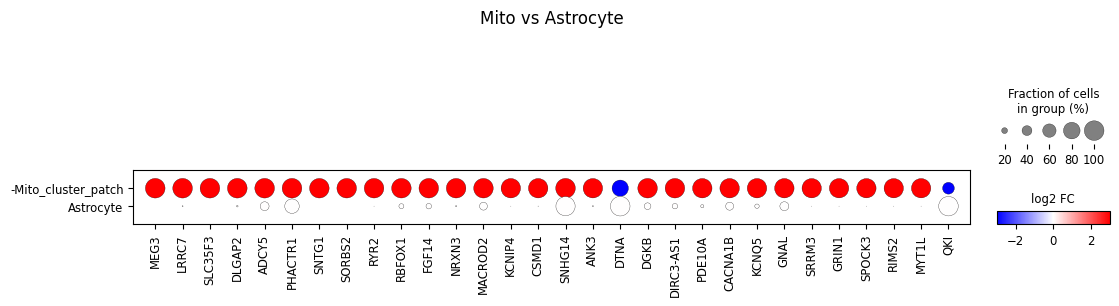


Comparing -Mito_cluster_patch vs Oligodendrocyte


... storing 'ct_for_deg_mpm x library' as categorical
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:912: RuntimeWarning: overflow encountered in expm1
  (expm1_func(mean_in_cluster) + 1e-9)


{'-Mito_cluster_patch': ['RYR3',
  'MEG3',
  'DLGAP2',
  'SLC35F3',
  'SNHG14',
  'PHACTR1',
  'QKI',
  'CELF2',
  'SORBS2',
  'DIRC3-AS1',
  'SNTG1',
  'DGKB',
  'FGF14',
  'RBFOX1',
  'PCDH9',
  'SYNE1',
  'RYR2',
  'MACROD2',
  'SHTN1',
  'CACNA2D3',
  'GNAL',
  'CACNB2',
  'CACNA1B',
  'KCNQ5',
  'STXBP5L',
  'PLCB1',
  'DLGAP1',
  'CSMD1',
  'TTLL7',
  'PCLO']}

,names,scores,logfoldchanges,pvals,pvals_adj,gene_symbol,pct_nz_group,group
0,RYR3,21.803963,34.710625,2.127717e-105,2.091783e-101,RYR3,1.000000,-Mito_cluster_patch
1,MEG3,21.803963,36.240158,2.127717e-105,2.091783e-101,MEG3,1.000000,-Mito_cluster_patch
2,DLGAP2,21.803963,34.431065,2.127717e-105,2.091783e-101,DLGAP2,1.000000,-Mito_cluster_patch
3,SLC35F3,21.800900,11.915697,2.275037e-105,2.091783e-101,SLC35F3,1.000000,-Mito_cluster_patch
4,SNHG14,21.789165,5.169807,2.939581e-105,2.162238e-101,SNHG14,1.000000,-Mito_cluster_patch
5,PHACTR1,21.751984,7.531891,6.615577e-105,3.475824e-101,PHACTR1,1.000000,-Mito_cluster_patch
6,QKI,-21.736477,-6.461572,9.275182e-105,4.264033e-101,QKI,0.506024,-Mito_cluster_patch
7,DIRC3-AS1,21.672615,33.941471,3.720239e-104,9.201501e-101,DIRC3-AS1,0.993976,-Mito_cluster_patch
8,SNTG1,21.672615,34.177521,3.720239e-104,9.201501e-101,SNTG1,0.993976,-Mito_cluster_patch
9,CELF2,21.672615,34.688618,3.720239e-104,9.201501e-101,CELF2,0.993976,-Mito_cluster_patch


Number of DEs: 1647


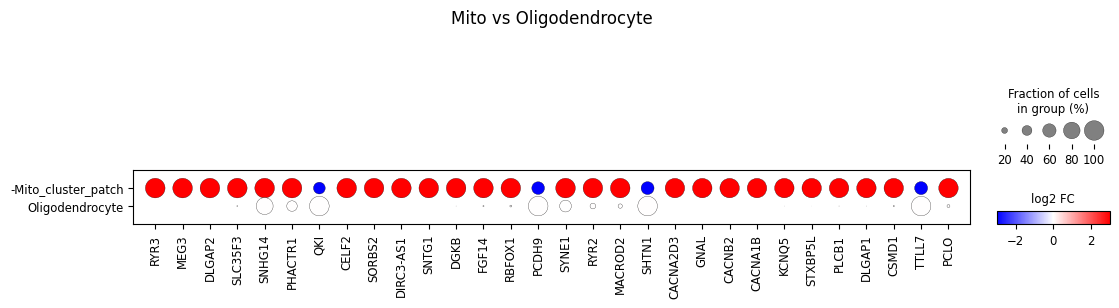


Comparing -Mito_cluster_patch vs Microglia


... storing 'ct_for_deg_mpm x library' as categorical
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:912: RuntimeWarning: overflow encountered in expm1
  (expm1_func(mean_in_cluster) + 1e-9)


{'-Mito_cluster_patch': ['LRRC7',
  'ADCY5',
  'MEG3',
  'DLGAP2',
  'RYR3',
  'SNHG14',
  'SYNE1',
  'SLC35F3',
  'PHACTR1',
  'RYR2',
  'PPP2R2B',
  'SNTG1',
  'DGKB',
  'SORBS2',
  'FGF14',
  'DIRC3-AS1',
  'NRXN3',
  'RBFOX1',
  'CSMD1',
  'PLCB1',
  'CACNA1B',
  'CACNB2',
  'LRP1B',
  'DLGAP1',
  'LSAMP',
  'GNAL',
  'STXBP5L',
  'MEIS2',
  'ANKS1B',
  'KCNQ5']}

,names,scores,logfoldchanges,pvals,pvals_adj,gene_symbol,pct_nz_group,group
0,LRRC7,18.607450,34.628929,2.796079e-77,1.313967e-73,LRRC7,1.000000,-Mito_cluster_patch
1,ADCY5,18.607450,33.451553,2.796079e-77,1.313967e-73,ADCY5,1.000000,-Mito_cluster_patch
2,MEG3,18.607450,36.240158,2.796079e-77,1.313967e-73,MEG3,1.000000,-Mito_cluster_patch
3,DLGAP2,18.607450,34.431065,2.796079e-77,1.313967e-73,DLGAP2,1.000000,-Mito_cluster_patch
4,RYR3,18.607450,34.710625,2.796079e-77,1.313967e-73,RYR3,1.000000,-Mito_cluster_patch
5,SNHG14,18.607450,10.064247,2.796079e-77,1.313967e-73,SNHG14,1.000000,-Mito_cluster_patch
6,SLC35F3,18.606274,13.560255,2.858160e-77,1.313967e-73,SLC35F3,1.000000,-Mito_cluster_patch
7,SYNE1,18.606274,8.792768,2.858160e-77,1.313967e-73,SYNE1,1.000000,-Mito_cluster_patch
8,PHACTR1,18.598036,8.727088,3.332955e-77,1.361994e-73,PHACTR1,1.000000,-Mito_cluster_patch
9,SORBS2,18.495358,33.494873,2.250437e-76,4.598144e-73,SORBS2,0.993976,-Mito_cluster_patch


Number of DEs: 1555


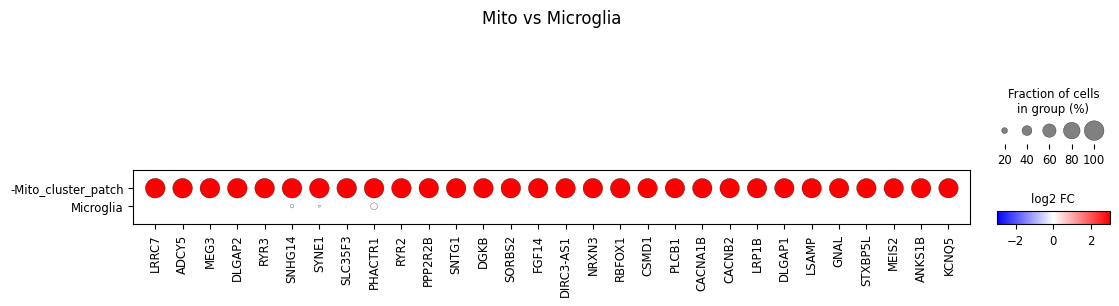


Comparing -Mito_cluster_patch vs eMSN_D1D2


... storing 'ct_for_deg_mpm x library' as categorical
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:912: RuntimeWarning: overflow encountered in expm1
  (expm1_func(mean_in_cluster) + 1e-9)


{'-Mito_cluster_patch': ['SLC35F3',
  'SPECC1',
  'GALNTL6',
  'NRXN1',
  'NALF1',
  'LDLRAD4',
  'FOXP1',
  'SORCS2',
  'GABRG3',
  'GPC5',
  'ARNT2',
  'SLC24A2',
  'NRG1',
  'PDZD2',
  'PRKCB',
  'ZMAT4',
  'ENSG00000228566',
  'MAGI2',
  'ANKRD30BL',
  'OPCML',
  'B3GALT1',
  'HTR2C',
  'PTPRD',
  'PBX3',
  'LDB2',
  'FRAS1',
  'DCLK1',
  'ERBB4',
  'SPOCK1',
  'NETO2']}

,names,scores,logfoldchanges,pvals,pvals_adj,gene_symbol,pct_nz_group,group
0,SLC35F3,15.743201,6.627275,7.647497e-56,2.427195e-51,SLC35F3,1.000000,-Mito_cluster_patch
1,SPECC1,-15.590200,-3.844415,8.486672e-55,8.144526e-51,SPECC1,0.680723,-Mito_cluster_patch
2,NRXN1,-15.573200,-3.855039,1.107255e-54,8.144526e-51,NRXN1,0.801205,-Mito_cluster_patch
3,GALNTL6,-15.573200,-3.192941,1.107255e-54,8.144526e-51,GALNTL6,0.939759,-Mito_cluster_patch
4,NALF1,-15.379399,-3.995901,2.250245e-53,1.034494e-49,NALF1,0.680723,-Mito_cluster_patch
5,LDLRAD4,15.178232,4.384546,4.928880e-52,1.720676e-48,LDLRAD4,0.981928,-Mito_cluster_patch
6,FOXP1,15.110799,3.830185,1.374639e-51,4.213038e-48,FOXP1,0.987952,-Mito_cluster_patch
7,SORCS2,-15.094932,-2.989286,1.748688e-51,4.947172e-48,SORCS2,0.831325,-Mito_cluster_patch
8,GABRG3,-14.902831,-3.063088,3.159060e-50,7.745594e-47,GABRG3,0.813253,-Mito_cluster_patch
9,GPC5,14.851264,6.563403,6.826916e-50,1.476943e-46,GPC5,0.963855,-Mito_cluster_patch


Number of DEs: 904


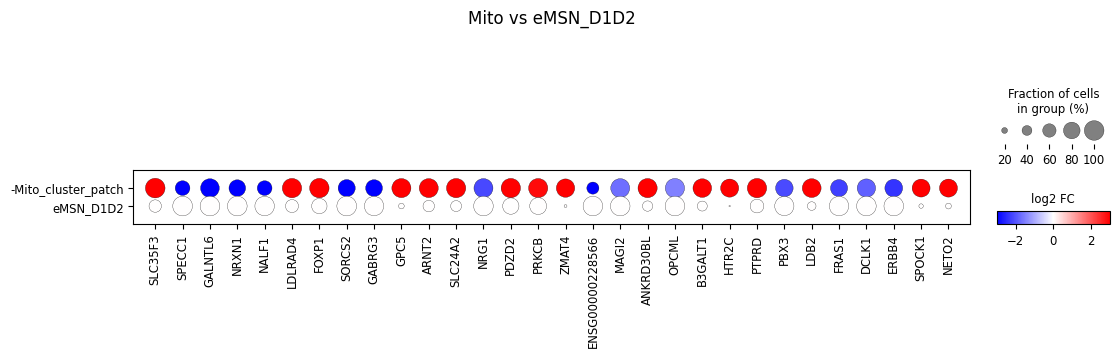


Comparing -Mito_cluster_patch vs patch


... storing 'ct_for_deg_mpm x library' as categorical
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:912: RuntimeWarning: overflow encountered in expm1
  (expm1_func(mean_in_cluster) + 1e-9)


{'-Mito_cluster_patch': ['MT-CO1',
  'MT-CO3',
  'MT-CO2',
  'MT-CYB',
  'MT-ND4',
  'MT-ATP6',
  'MT-ND1',
  'MT-ND4L',
  'MT-ND2',
  'MT-ND3',
  'MT-ND5',
  'ENSG00000289901',
  'MEG3',
  'GNG7',
  'LINC00342',
  'PNISR',
  'DST',
  'ANKRD30BL',
  'SRRM3',
  'GPR149',
  'ZNF91',
  'CACNA1B',
  'ADAM22',
  'SNHG14',
  'PCNT',
  'FOCAD',
  'RUNX1T1',
  'ABLIM2',
  'CDK17',
  'DGKI']}

,names,scores,logfoldchanges,pvals,pvals_adj,gene_symbol,pct_nz_group,group
0,MT-CO1,17.799078,2.790117,7.184256e-71,1.505334e-66,MT-CO1,1.000000,-Mito_cluster_patch
1,MT-CO3,17.790201,2.898600,8.417819e-71,1.505334e-66,MT-CO3,1.000000,-Mito_cluster_patch
2,MT-CO2,17.769032,3.074916,1.227908e-70,1.505334e-66,MT-CO2,1.000000,-Mito_cluster_patch
3,MT-CYB,17.488724,2.995167,1.746243e-68,1.605583e-64,MT-CYB,0.993976,-Mito_cluster_patch
4,MT-ND4,17.448437,2.853469,3.537892e-68,2.602332e-64,MT-ND4,0.993976,-Mito_cluster_patch
5,MT-ATP6,17.224804,3.003872,1.730141e-66,1.060519e-62,MT-ATP6,0.987952,-Mito_cluster_patch
6,MT-ND1,16.960543,2.933172,1.608540e-64,8.451267e-61,MT-ND1,0.987952,-Mito_cluster_patch
7,MT-ND4L,16.593853,2.597382,7.720413e-62,3.549267e-58,MT-ND4L,0.987952,-Mito_cluster_patch
8,MT-ND2,16.475039,2.815474,5.545364e-61,2.266082e-57,MT-ND2,0.981928,-Mito_cluster_patch
9,MT-ND3,15.623870,3.094852,5.007207e-55,1.841551e-51,MT-ND3,0.951807,-Mito_cluster_patch


Number of DEs: 954


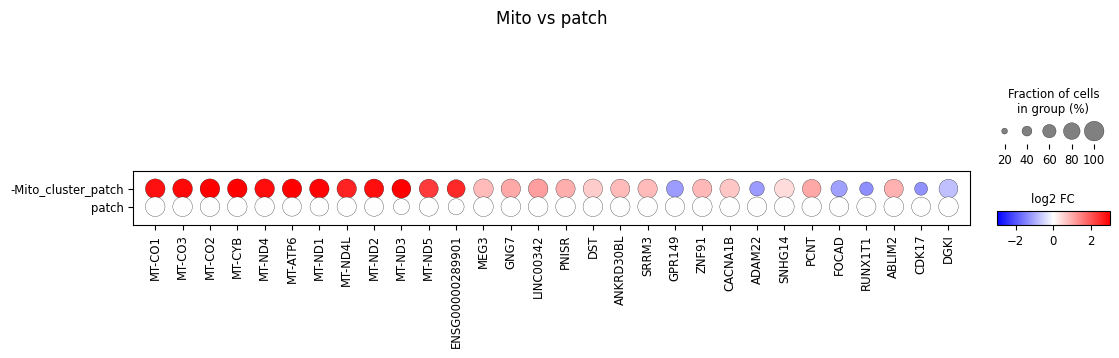


Comparing -Mito_cluster_patch vs matrix


... storing 'ct_for_deg_mpm x library' as categorical
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:912: RuntimeWarning: overflow encountered in expm1
  (expm1_func(mean_in_cluster) + 1e-9)


{'-Mito_cluster_patch': ['MT-CO1',
  'MT-CO2',
  'MT-CO3',
  'MT-CYB',
  'MT-ND4',
  'MT-ATP6',
  'MT-ND1',
  'MT-ND4L',
  'MT-ND2',
  'MT-ND3',
  'MT-ND5',
  'GNG7',
  'COCH',
  'ENSG00000289901',
  'ENSG00000259336',
  'SH3GL3',
  'ATP8A1',
  'MAP3K5',
  'CACNA1B',
  'LINC00342',
  'SGCZ',
  'SRRM3',
  'GRIN1',
  'PCDH9',
  'ITGB8',
  'MEG3',
  'SNHG14',
  'WDFY3',
  'PNISR',
  'QKI']}

,names,scores,logfoldchanges,pvals,pvals_adj,gene_symbol,pct_nz_group,group
0,MT-CO1,11.186626,2.620991,4.741312e-29,1.743760e-24,MT-CO1,1.000000,-Mito_cluster_patch
1,MT-CO2,11.052472,2.878285,2.132611e-28,2.755182e-24,MT-CO2,1.000000,-Mito_cluster_patch
2,MT-CO3,11.047765,2.615499,2.247416e-28,2.755182e-24,MT-CO3,1.000000,-Mito_cluster_patch
3,MT-CYB,10.899488,2.614104,1.159074e-27,1.008544e-23,MT-CYB,0.993976,-Mito_cluster_patch
4,MT-ND4,10.884190,2.687510,1.371124e-27,1.008544e-23,MT-ND4,0.993976,-Mito_cluster_patch
5,MT-ATP6,10.824173,3.011005,2.644551e-27,1.621022e-23,MT-ATP6,0.987952,-Mito_cluster_patch
6,MT-ND1,10.715908,2.812551,8.571210e-27,4.503314e-23,MT-ND1,0.987952,-Mito_cluster_patch
7,MT-ND4L,10.464073,2.585845,1.263061e-25,5.806607e-22,MT-ND4L,0.987952,-Mito_cluster_patch
8,MT-ND2,10.234598,2.593475,1.387700e-24,5.670759e-21,MT-ND2,0.981928,-Mito_cluster_patch
9,MT-ND3,9.932161,3.024306,3.016445e-23,1.109388e-19,MT-ND3,0.951807,-Mito_cluster_patch


Number of DEs: 638


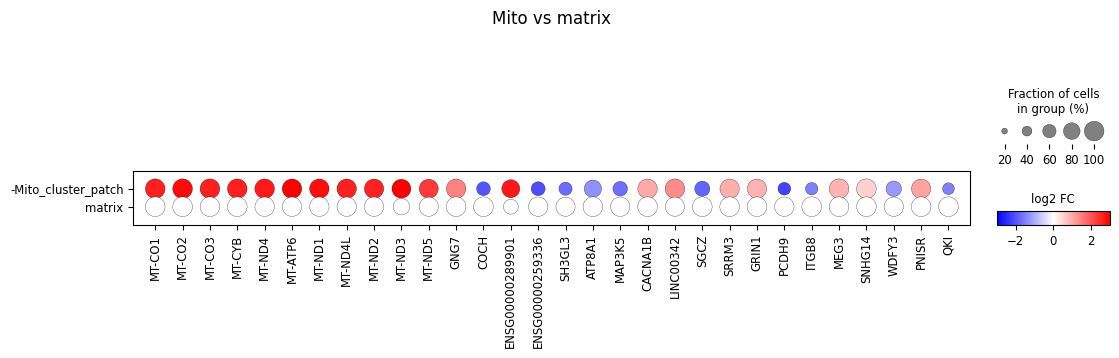


Comparing -Mito_cluster_patch vs eMSN_NUDAP


... storing 'ct_for_deg_mpm x library' as categorical
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:912: RuntimeWarning: overflow encountered in expm1
  (expm1_func(mean_in_cluster) + 1e-9)


{'-Mito_cluster_patch': ['SLC24A2',
  'PDZD2',
  'ERBB4',
  'FOXP1',
  'MEG3',
  'SLC35F3',
  'LDLRAD4',
  'PBX3',
  'GNG7',
  'GPC5',
  'DLC1',
  'CAMK4',
  'DACH1',
  'NRXN1',
  'PPFIA2',
  'CSMD1',
  'PRKCB',
  'INPP5A',
  'ROBO2',
  'EPHA6',
  'MT-CO3',
  'ARNT2',
  'CACNA1B',
  'SRRM3',
  'ZMAT4',
  'MT-ATP6',
  'MT-CYB',
  'TTLL11',
  'MT-ND1',
  'DGKB']}

,names,scores,logfoldchanges,pvals,pvals_adj,gene_symbol,pct_nz_group,group
0,SLC24A2,6.056843,34.181358,1.388188e-09,0.000004,SLC24A2,0.975904,-Mito_cluster_patch
1,PDZD2,6.038149,5.784896,1.558919e-09,0.000004,PDZD2,0.981928,-Mito_cluster_patch
2,ERBB4,-5.998091,-3.011315,1.996510e-09,0.000004,ERBB4,0.873494,-Mito_cluster_patch
3,FOXP1,5.992750,4.153980,2.063224e-09,0.000004,FOXP1,0.987952,-Mito_cluster_patch
4,MEG3,5.987409,1.580622,2.132109e-09,0.000004,MEG3,1.000000,-Mito_cluster_patch
5,SLC35F3,5.944679,3.671754,2.769984e-09,0.000005,SLC35F3,1.000000,-Mito_cluster_patch
6,LDLRAD4,5.931326,4.195144,3.004969e-09,0.000005,LDLRAD4,0.981928,-Mito_cluster_patch
7,PBX3,-5.928656,-2.287072,3.054242e-09,0.000005,PBX3,0.861446,-Mito_cluster_patch
8,GNG7,5.917974,3.407316,3.259320e-09,0.000005,GNG7,0.987952,-Mito_cluster_patch
9,GPC5,5.869904,6.374980,4.360487e-09,0.000006,GPC5,0.963855,-Mito_cluster_patch


Number of DEs: 485


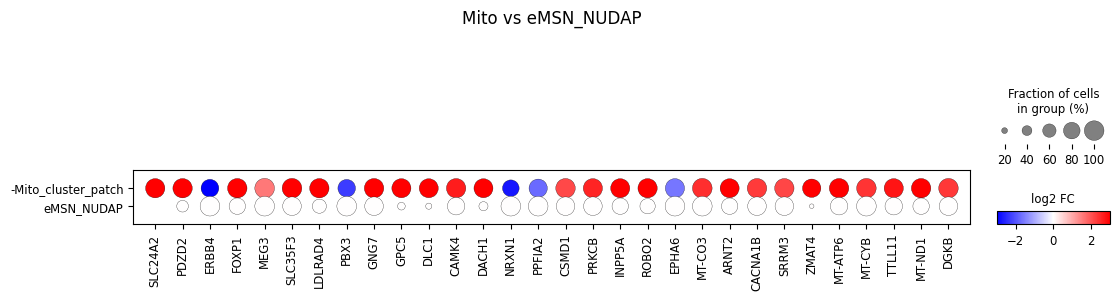


Comparing -Mito_cluster_patch vs eMSN_StrioMat


... storing 'ct_for_deg_mpm x library' as categorical
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:912: RuntimeWarning: overflow encountered in expm1
  (expm1_func(mean_in_cluster) + 1e-9)


{'-Mito_cluster_patch': ['KCNIP4',
  'NRG3',
  'GPC5',
  'SLC35F3',
  'TENM1',
  'SEMA6D',
  'GABRG3',
  'B3GALT1',
  'GRM5',
  'PTPRT',
  'ARNT2',
  'SORCS1',
  'CNTN5',
  'EYA1',
  'NETO1',
  'HTR2C',
  'ZNF804A',
  'ERBB4',
  'PRKCB',
  'GALNT18',
  'ANKRD30BL',
  'LRP1B',
  'PDZD2',
  'LDLRAD4',
  'CHST11',
  'DCLK1',
  'NRG1',
  'RGS12',
  'HS6ST3',
  'LINC01322']}

,names,scores,logfoldchanges,pvals,pvals_adj,gene_symbol,pct_nz_group,group
0,KCNIP4,7.544662,4.917237,4.534629e-14,1.170169e-09,KCNIP4,0.987952,-Mito_cluster_patch
1,NRG3,7.479587,6.754353,7.455682e-14,1.170169e-09,NRG3,0.969880,-Mito_cluster_patch
2,GPC5,7.447049,8.928873,9.545126e-14,1.170169e-09,GPC5,0.963855,-Mito_cluster_patch
3,SLC35F3,7.231487,3.035433,4.777334e-13,4.392520e-09,SLC35F3,1.000000,-Mito_cluster_patch
4,TENM1,-6.926447,-2.717297,4.315418e-12,2.645207e-08,TENM1,0.638554,-Mito_cluster_patch
5,SEMA6D,-6.820700,-2.446334,9.059821e-12,4.760030e-08,SEMA6D,0.945783,-Mito_cluster_patch
6,GABRG3,-6.658011,-2.370021,2.775571e-11,1.134222e-07,GABRG3,0.813253,-Mito_cluster_patch
7,B3GALT1,6.617340,2.988620,3.657211e-11,1.345049e-07,B3GALT1,0.933735,-Mito_cluster_patch
8,GRM5,6.601070,2.183191,4.081990e-11,1.364795e-07,GRM5,0.969880,-Mito_cluster_patch
9,PTPRT,-6.527861,-2.130733,6.671557e-11,1.752618e-07,PTPRT,0.903614,-Mito_cluster_patch


Number of DEs: 211


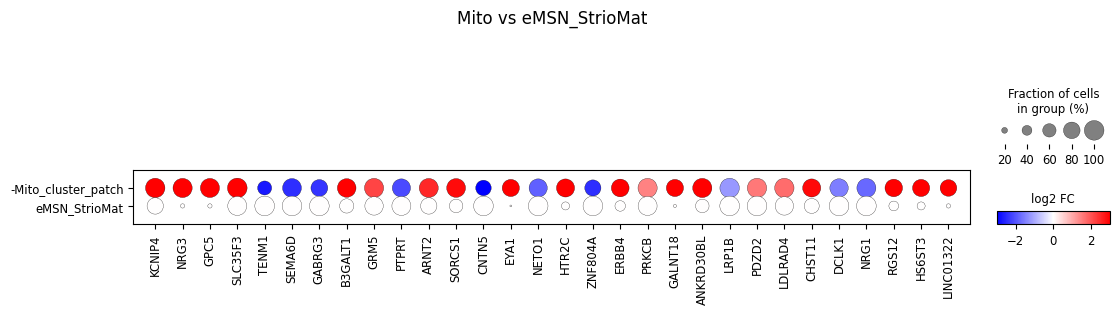

In [ ]:
ct_col = "ct_for_deg_mpm"
mito_label = "-Mito_cluster_patch"

other_groups = [
    g for g in adata_slice_dead.obs[ct_col].unique()
    if g != mito_label and pd.notna(g) and not str(g).startswith("-")
]

results = {}

for other_ct in other_groups:
    print(f"\nComparing {mito_label} vs {other_ct}")

    adata_tmp = adata_slice_dead.copy()

    df, _, genes = deg_wilcoxon(
        adata_tmp,
        group_col=ct_col,
        gene_symbol_col="gene_symbol",
        layer="log1p_norm",
        groups=[mito_label],
        reference=other_ct,
        min_in_group_fraction=0.5,
        max_out_group_fraction=1,
        only_upregulated=False,
        n_genes_per_group=30,
    )

    df_mito = df[df["group"] == mito_label].copy()
    top_genes = genes.get(mito_label, [])

    display(df_mito.head(20))
    print(f"Number of DEs: {df_mito.shape[0]}")

    save_dir = f"/home/gdallagl/myworkdir/XDP/data/_old/mito_patch_degs/{SAMPLE}"
    os.makedirs(save_dir, exist_ok=True)
    df_mito.to_csv(f"{save_dir}/DEGs_{mito_label}_vs_{other_ct}_in_dead_region.csv", index=False)

    results[other_ct] = {"df": df_mito, "top_genes": top_genes}

    if top_genes:
        # subset + clean categories for dot_size_df
        mask = adata_tmp.obs[ct_col].isin([mito_label, other_ct])
        adata_plot = adata_tmp[mask].copy()
        adata_plot.obs[ct_col] = adata_plot.obs[ct_col].cat.remove_unused_categories()

        # ✅ build dot_color_df manually — both groups as rows, top_genes as columns
        # mito row: actual logFC from DEG results
        # other_ct row: all zeros (it's the reference, logFC is defined relative to it)
        logfc_series = (
            df_mito.set_index("names")["logfoldchanges"]
            .reindex(top_genes)
            .fillna(0)
        )
        dot_color_df = pd.DataFrame(
            [logfc_series.values,
             [0.0] * len(top_genes)],       # reference group → logFC = 0 by definition
            index=[mito_label, other_ct],
            columns=top_genes,
        )

        sc.pl.dotplot(
            adata_plot,
            var_names=top_genes,
            groupby=ct_col,
            dot_color_df=dot_color_df,      # inject our manually built logFC matrix
            cmap="bwr",
            vmin=-3, vmax=3,
            colorbar_title="log2 FC",
            use_raw=False,
            layer="log1p_norm",
            title=f"Mito vs {other_ct}",
            show=True,
        )

        del adata_plot

    del adata_tmp

In [45]:
STOP

NameError: name 'STOP' is not defined

# DEG 

cell types that is in close to mitoaotch Vs same cell typoe not close

single slice

only dead region


── Microglia ──
in_mito_hull
outside    323
inside      58
Name: count, dtype: int64


{}

  no significant genes for Microglia, skipping plot

── Astrocyte ──
in_mito_hull
outside    348
inside      57
Name: count, dtype: int64


/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:913: RuntimeWarning: overflow encountered in expm1
  / (expm1_func(mean_out_cluster) + 1e-9)
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:911: RuntimeWarning: divide by zero encountered in log2
  fold_change_matrix.loc[:, cluster] = np.log2(


{'inside': ['SLC1A2',
  'MT-CO3',
  'MT-CYB',
  'SLC38A1',
  'MALAT1',
  'CPE',
  'ATP1B2',
  'MT-ND1',
  'DCLK1',
  'MT-CO2']}

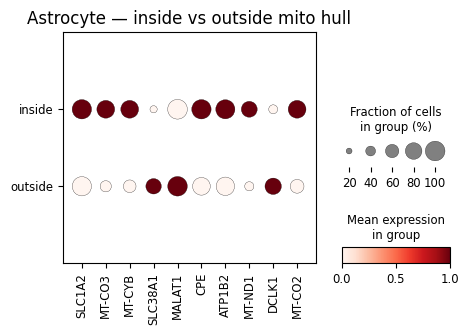


── Oligodendrocyte ──
in_mito_hull
outside    3043
inside      472
Name: count, dtype: int64


{'inside': ['CADM2',
  'CRYAB',
  'MALAT1',
  'NCAM2',
  'SHTN1',
  'GAPDH',
  'HNRNPA2B1',
  'NEAT1',
  'PEBP1',
  'GLUL']}

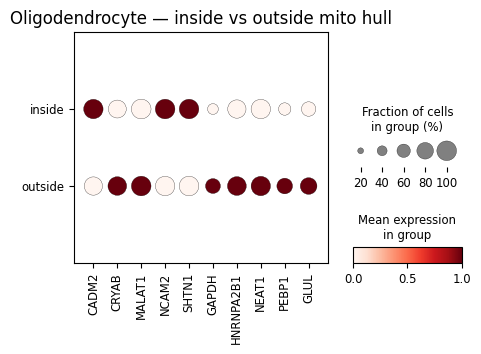

In [ ]:
# ── Choose cell types to analyse ─────────────────────────────────────────────
CELL_TYPES = ["Microglia", "Astrocyte", "Oligodendrocyte"]   # <-- change this

# ── Loop ─────────────────────────────────────────────────────────────────────
results_hull = {}

for CELL_TYPE in CELL_TYPES:
    print(f"\n── {CELL_TYPE} ──")
    
    mask_ct = adata_slice_dead.obs["ct_for_deg"] == CELL_TYPE
    adata_ct = adata_slice_dead[mask_ct].copy()

    # check enough cells in both groups before running
    counts = adata_ct.obs["in_mito_hull"].value_counts()
    print(counts)
    if counts.get("inside", 0) < 10 or counts.get("outside", 0) < 10:
        print(f"  skipping {CELL_TYPE} — not enough cells in one group")
        continue

    df, key, genes = deg_wilcoxon(
        adata_ct,
        group_col="in_mito_hull",
        groups=["inside"],
        reference="outside",
        gene_symbol_col="gene_symbol",
        layer="log1p_norm",
        min_in_group_fraction=0.25,
        max_out_group_fraction=1,
        min_fold_change=0.5,
        only_upregulated=False,
        n_genes_per_group=10,
    )

    results_hull[CELL_TYPE] = {"df": df, "top_genes": genes.get("inside", [])}
    
    top_genes = genes.get("inside", [])

    if len(top_genes) == 0:
        print(f"  no significant genes for {CELL_TYPE}, skipping plot")
        continue

    sc.pl.dotplot(
        adata_ct,
        var_names=top_genes,
        groupby="in_mito_hull",
        use_raw=False,
        layer="log1p_norm",
        standard_scale="var",
        title=f"{CELL_TYPE} — inside vs outside mito hull",
        figsize=(max(5, len(top_genes) * 0.5), 3),  # width scales with number of genes
        show=True
    )

# Does Mito_cluster_patch come just form neUN+ libraries?

... storing 'ct_for_deg_mpm x library' as categorical
... storing 'is_neun' as categorical


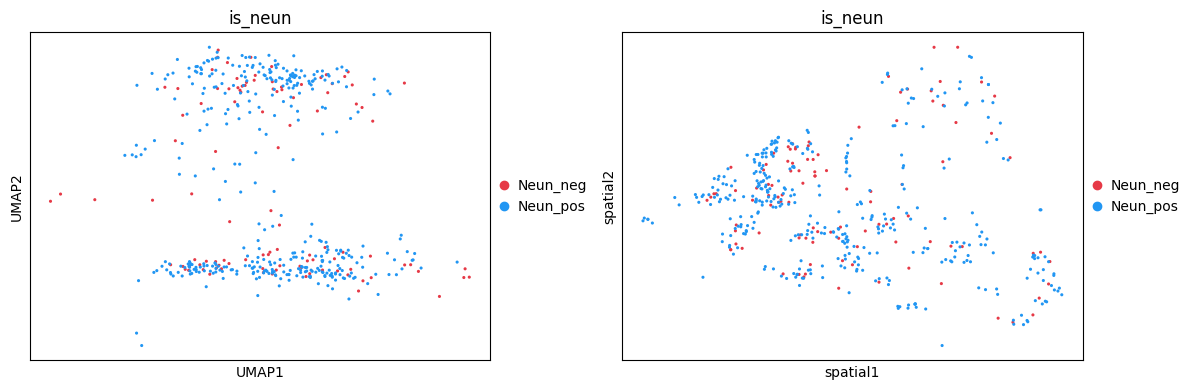

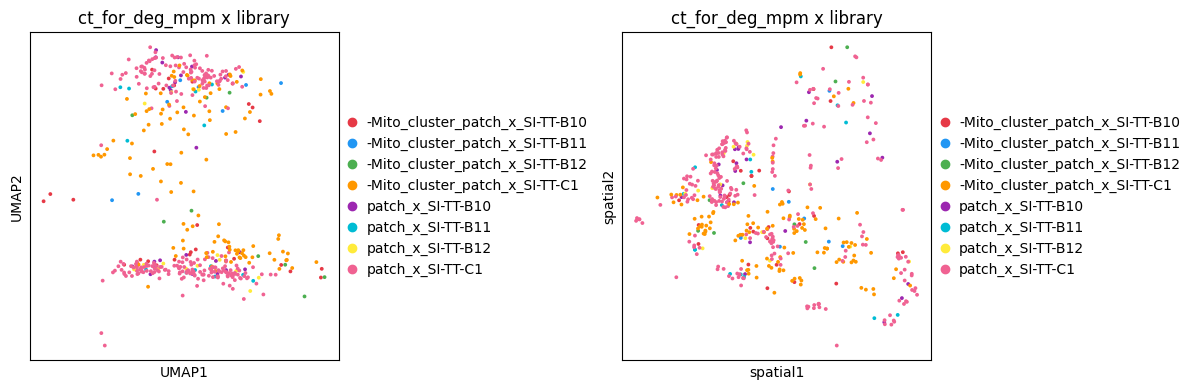

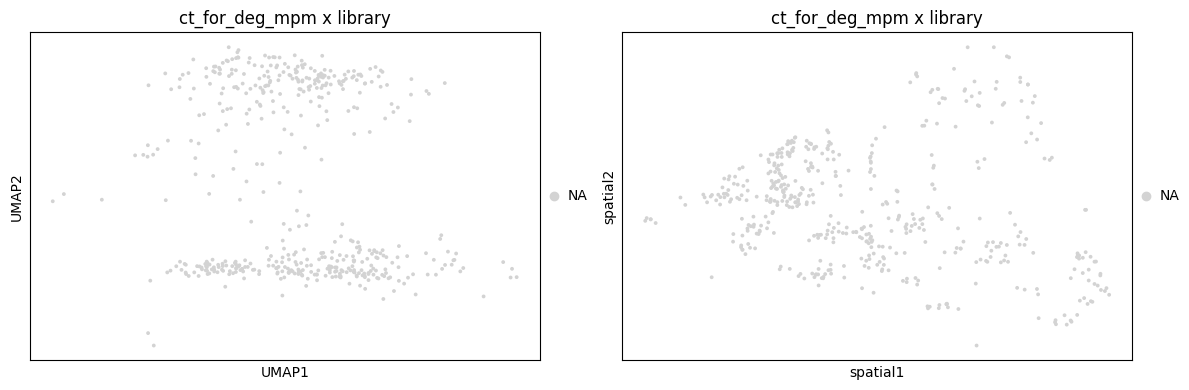

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


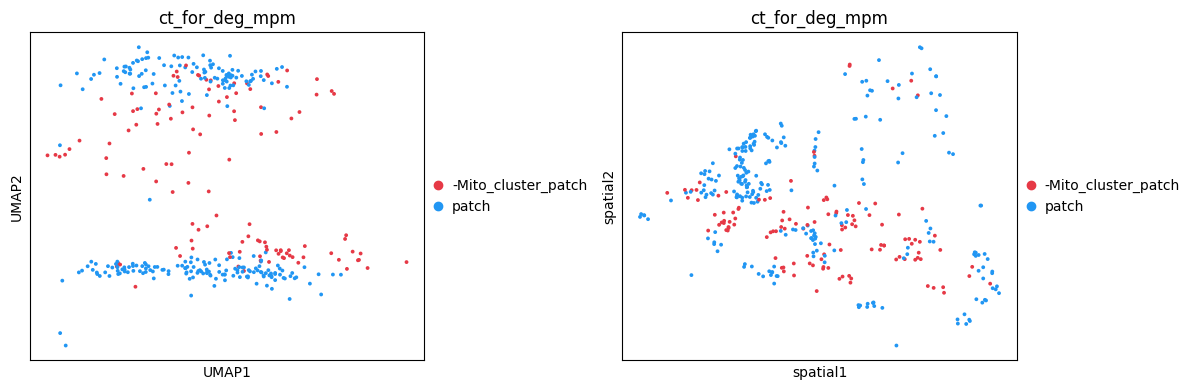

... storing 'ct_neun' as categorical


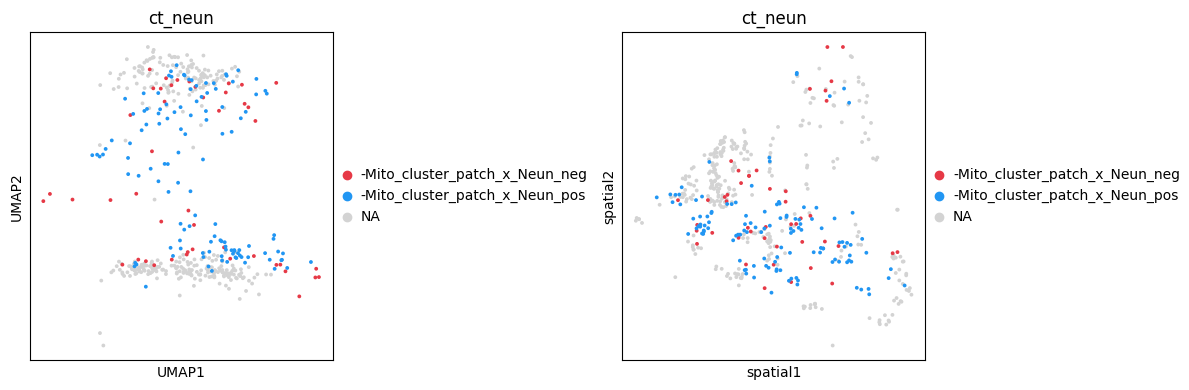

is_neun,Neun_neg,Neun_pos
ct_for_deg_mpm,,
-Mito_cluster_patch,46,120
patch,59,260


In [57]:
# add library anme
adata_slice_dead.obs["ct_for_deg_mpm x library"] = adata_slice_dead.obs["ct_for_deg_mpm"].astype(str) + "_x_" + adata_slice_dead.obs["library_name"].astype(str)

adata_slice_dead_patch = adata_slice_dead[adata_slice_dead.obs["ct_for_deg_mpm"].isin(["patch", "-Mito_cluster_patch"])].copy()

neun = {lib: "Neun_pos" for lib in sample_infos[SAMPLE]["neun_pos_libraries"]}
adata_slice_dead_patch.obs["is_neun"] = (
    adata_slice_dead_patch.obs["library_name"]
    .map(neun)
    .fillna("Neun_neg")
)
lmu.plot_umap_spatial(adata_slice_dead_patch, color=["is_neun"],name="", ncols=1, size=20, palette=preprocessing.custom_palette)


lmu.plot_umap_spatial(adata_slice_dead_patch, color=["ct_for_deg_mpm x library"], name="", ncols=1, size=30, palette=preprocessing.custom_palette)


lmu.plot_umap_spatial(adata_slice_dead_patch, color=["ct_for_deg_mpm x library"], groups=["-Mito_cluster_patch"], ncols=1, size=30, palette=preprocessing.custom_palette)

lmu.plot_umap_spatial(
    adata_slice_dead_patch[adata_slice_dead_patch.obs["is_neun"] == "Neun_pos"],
    color=["ct_for_deg_mpm"],
    groups=["patch", "-Mito_cluster_patch"],
    ncols=1, size=30,
    palette=preprocessing.custom_palette
)

adata_slice_dead_patch.obs["ct_neun"] = (
    adata_slice_dead_patch.obs["ct_for_deg_mpm"].astype(str) + "_x_" + 
    adata_slice_dead_patch.obs["is_neun"].astype(str)
)
lmu.plot_umap_spatial(
    adata_slice_dead_patch,
    color=["ct_neun"],
    groups=["-Mito_cluster_patch_x_Neun_neg", "-Mito_cluster_patch_x_Neun_pos"],
    ncols=1, size=30,
    palette=preprocessing.custom_palette
)

pd.crosstab(
    adata_slice_dead_patch.obs["ct_for_deg_mpm"],
    adata_slice_dead_patch.obs["is_neun"]
)

# ---

In [ ]:
stop

### Cehck DEGs etween cells of same type and zone between deah and nromal region


Analyzing ct=Matrix_D1, zone=5
  Skipping: not enough cells in both groups ({'False': 358})

Analyzing ct=Matrix_D1, zone=4


... storing 'zone_x_region_x_ct' as categorical
... storing 'is_mito' as categorical


  Skipping: not enough cells in both groups ({'False': 841})

Analyzing ct=Matrix_D1, zone=1


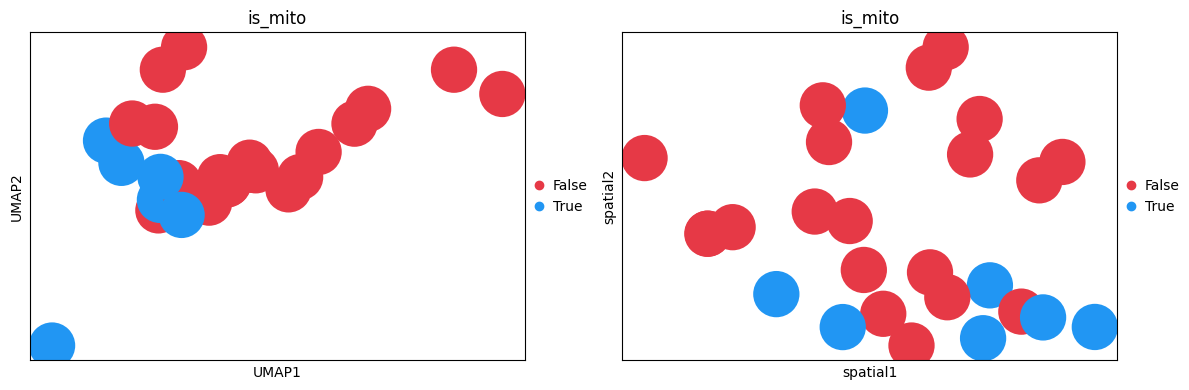

,names,scores,logfoldchanges,pvals,pvals_adj,gene_symbol


... storing 'zone_x_region_x_ct' as categorical
... storing 'is_mito' as categorical



Analyzing ct=Matrix_D1, zone=3
  Skipping: not enough cells in both groups ({'False': 107})

Analyzing ct=Matrix_D1, zone=2


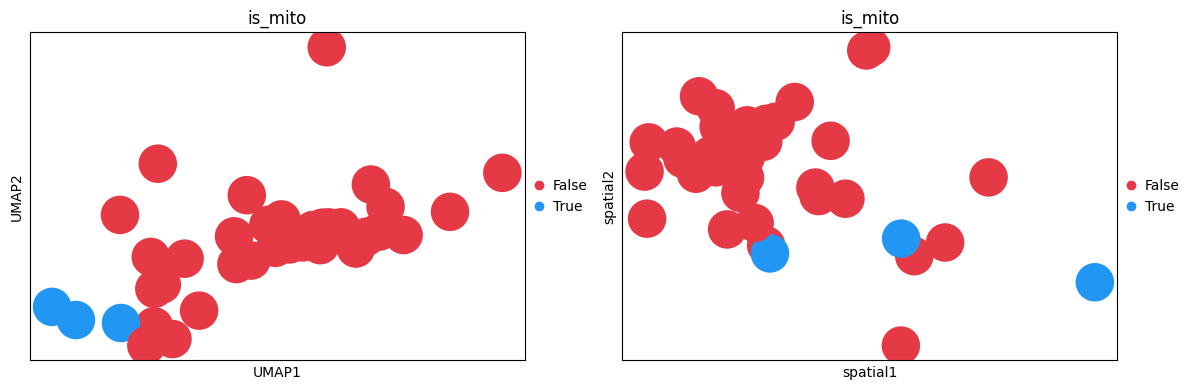

,names,scores,logfoldchanges,pvals,pvals_adj,gene_symbol



Analyzing ct=Matrix_D1, zone=6
  Skipping: not enough cells in both groups ({'False': 99})

Analyzing ct=Matrix_D2, zone=5
  Skipping: not enough cells in both groups ({'False': 480})

Analyzing ct=Matrix_D2, zone=4


... storing 'zone_x_region_x_ct' as categorical
... storing 'is_mito' as categorical


  Skipping: not enough cells in both groups ({'False': 711})

Analyzing ct=Matrix_D2, zone=3
  Skipping: not enough cells in both groups ({'False': 134})

Analyzing ct=Matrix_D2, zone=2


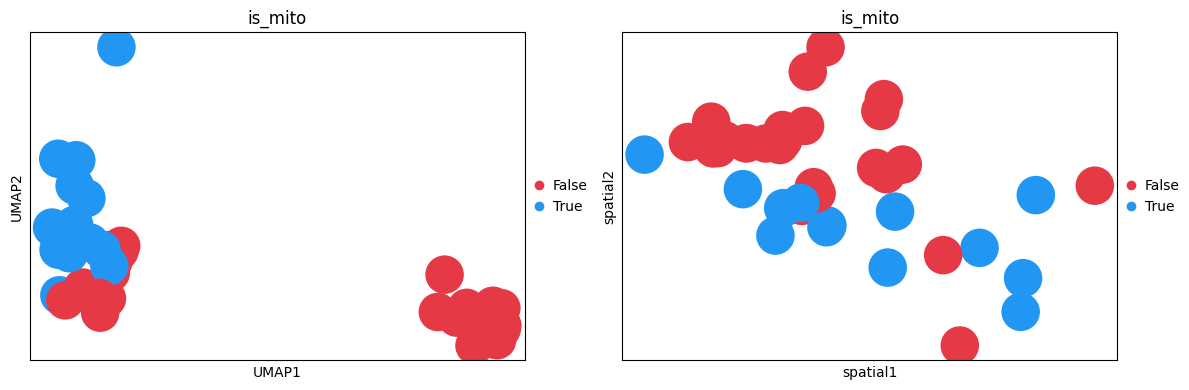

,names,scores,logfoldchanges,pvals,pvals_adj,gene_symbol
0,ENSG00000100815,5.034878,2.282394,4.781524e-07,0.007481,TRIP11
1,ENSG00000198804,4.826333,2.807419,1.390698e-06,0.007481,MT-CO1
2,ENSG00000198727,4.796541,3.159827,1.614290e-06,0.007481,MT-CYB
3,ENSG00000198888,4.766749,2.898538,1.872226e-06,0.007481,MT-ND1
4,ENSG00000198763,4.736957,2.805861,2.169517e-06,0.007481,MT-ND2
5,ENSG00000198938,4.677372,2.941413,2.905746e-06,0.007481,MT-CO3
6,ENSG00000198899,4.677372,2.807820,2.905746e-06,0.007481,MT-ATP6
7,ENSG00000198712,4.677372,3.041187,2.905746e-06,0.007481,MT-CO2
8,ENSG00000159842,4.647580,1.673231,3.358518e-06,0.007481,ABR
9,ENSG00000198786,4.647580,2.260640,3.358518e-06,0.007481,MT-ND5


... storing 'zone_x_region_x_ct' as categorical
... storing 'is_mito' as categorical



Analyzing ct=Matrix_D2, zone=1


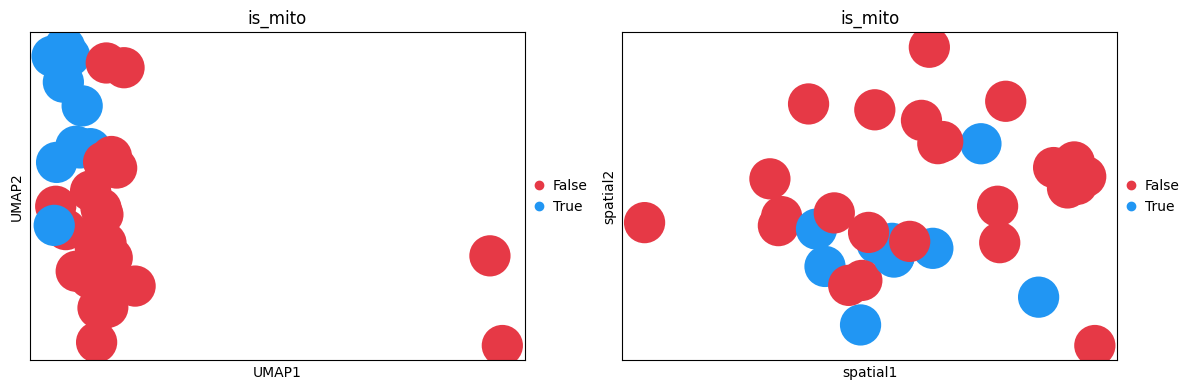

,names,scores,logfoldchanges,pvals,pvals_adj,gene_symbol


... storing 'zone_x_region_x_ct' as categorical
... storing 'is_mito' as categorical



Analyzing ct=Matrix_D2, zone=nan
  Skipping: not enough cells in both groups ({})

Analyzing ct=Matrix_D2, zone=6
  Skipping: not enough cells in both groups ({'False': 83, 'True': 2})

Analyzing ct=Patch_D1, zone=Ventral
  Skipping: not enough cells in both groups ({'False': 234})

Analyzing ct=Patch_D1, zone=Caudate


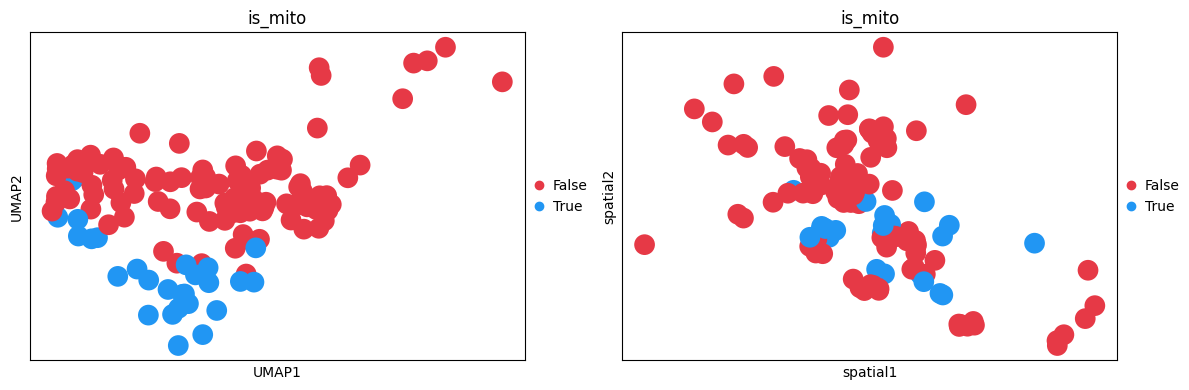

,names,scores,logfoldchanges,pvals,pvals_adj,gene_symbol
0,ENSG00000198804,7.861986,2.614129,3.780918e-15,5.419608e-11,MT-CO1
1,ENSG00000198938,7.850826,2.822592,4.133066e-15,5.419608e-11,MT-CO3
2,ENSG00000198712,7.839666,2.908929,4.517458e-15,5.419608e-11,MT-CO2
3,ENSG00000198886,7.806187,2.852463,5.894402e-15,5.419608e-11,MT-ND4
4,ENSG00000198899,7.755969,2.952891,8.767167e-15,6.448777e-11,MT-ATP6
5,ENSG00000198888,7.716910,2.960676,1.191839e-14,7.305576e-11,MT-ND1
6,ENSG00000198727,7.585784,2.733696,3.304832e-14,1.620579e-10,MT-CYB
7,ENSG00000212907,7.577414,2.568261,3.525105e-14,1.620579e-10,MT-ND4L
8,ENSG00000198763,7.343061,2.623034,2.087633e-13,8.530998e-10,MT-ND2
9,ENSG00000198840,7.225884,3.242608,4.978508e-13,1.830996e-09,MT-ND3


... storing 'zone_x_region_x_ct' as categorical
... storing 'is_mito' as categorical



Analyzing ct=Patch_D1, zone=Putamen
  Skipping: not enough cells in both groups ({'False': 131})

Analyzing ct=Patch_D1, zone=Dorsal


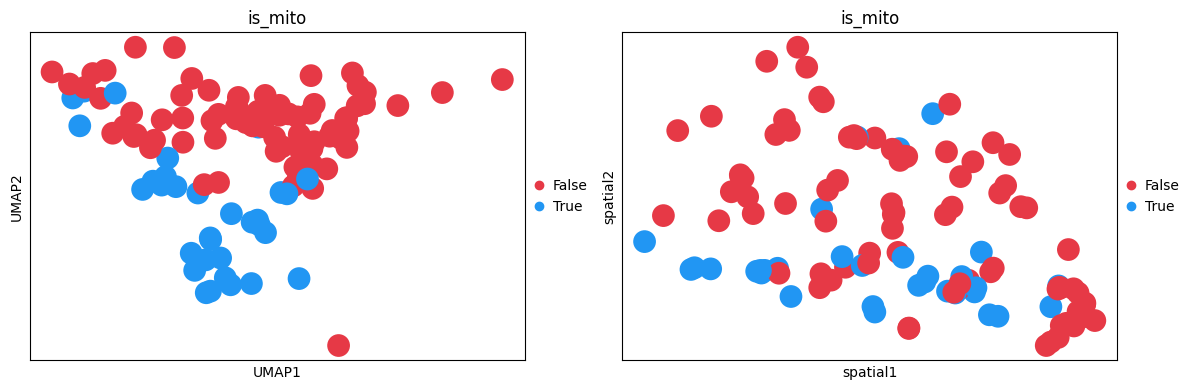

,names,scores,logfoldchanges,pvals,pvals_adj,gene_symbol
0,ENSG00000198938,8.037963,2.898737,9.134418e-16,9.696465e-12,MT-CO3
1,ENSG00000198899,8.025082,2.932580,1.014584e-15,9.696465e-12,MT-ATP6
2,ENSG00000198712,8.012200,2.927044,1.126741e-15,9.696465e-12,MT-CO2
3,ENSG00000198727,7.992878,2.700543,1.318243e-15,9.696465e-12,MT-CYB
4,ENSG00000198886,7.992878,2.742090,1.318243e-15,9.696465e-12,MT-ND4
5,ENSG00000198804,7.954234,2.664731,1.802428e-15,1.104828e-11,MT-CO1
6,ENSG00000212907,7.599997,2.476848,2.961374e-14,1.555906e-10,MT-ND4L
7,ENSG00000198888,7.387455,2.540781,1.496660e-13,6.880520e-10,MT-ND1
8,ENSG00000198763,7.323048,2.590323,2.424010e-13,9.905581e-10,MT-ND2
9,ENSG00000198786,6.894743,1.970543,5.396222e-12,1.984623e-08,MT-ND5


... storing 'zone_x_region_x_ct' as categorical
... storing 'is_mito' as categorical



Analyzing ct=Patch_D2, zone=Ventral


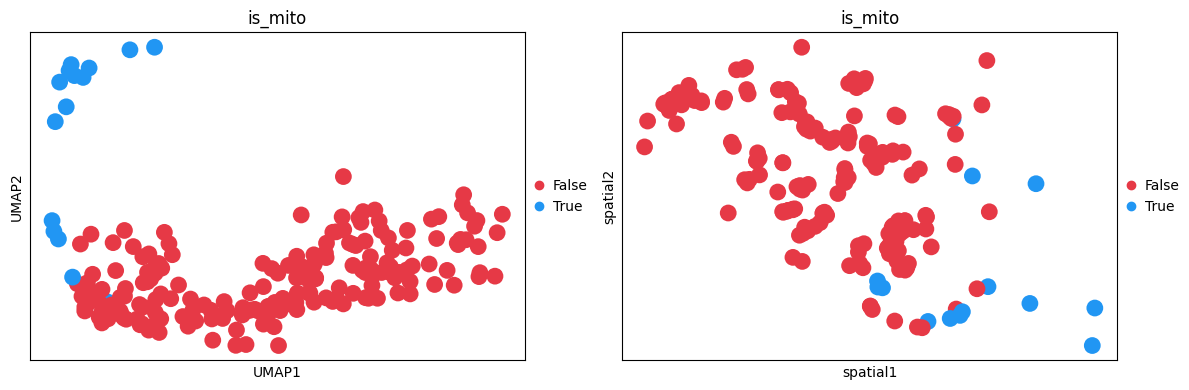

,names,scores,logfoldchanges,pvals,pvals_adj,gene_symbol
0,ENSG00000198712,6.633251,3.975537,3.283727e-11,2.930335e-07,MT-CO2
1,ENSG00000198938,6.611417,3.884813,3.806592e-11,2.930335e-07,MT-CO3
2,ENSG00000198888,6.607050,4.315912,3.920539e-11,2.930335e-07,MT-ND1
3,ENSG00000198763,6.598316,3.904285,4.158536e-11,2.930335e-07,MT-ND2
4,ENSG00000198804,6.589582,3.521904,4.410652e-11,2.930335e-07,MT-CO1
5,ENSG00000212907,6.567748,3.229674,5.108182e-11,2.930335e-07,MT-ND4L
6,ENSG00000198886,6.554647,3.762211,5.577341e-11,2.930335e-07,MT-ND4
7,ENSG00000198786,6.393074,3.152534,1.625835e-10,7.474368e-07,MT-ND5
8,ENSG00000198899,5.847218,4.153307,4.998643e-09,1.671273e-05,MT-ATP6
9,ENSG00000198840,5.801365,3.904329,6.577710e-09,2.015959e-05,MT-ND3


... storing 'zone_x_region_x_ct' as categorical
... storing 'is_mito' as categorical



Analyzing ct=Patch_D2, zone=Putamen
  Skipping: not enough cells in both groups ({'False': 122})

Analyzing ct=Patch_D2, zone=Dorsal


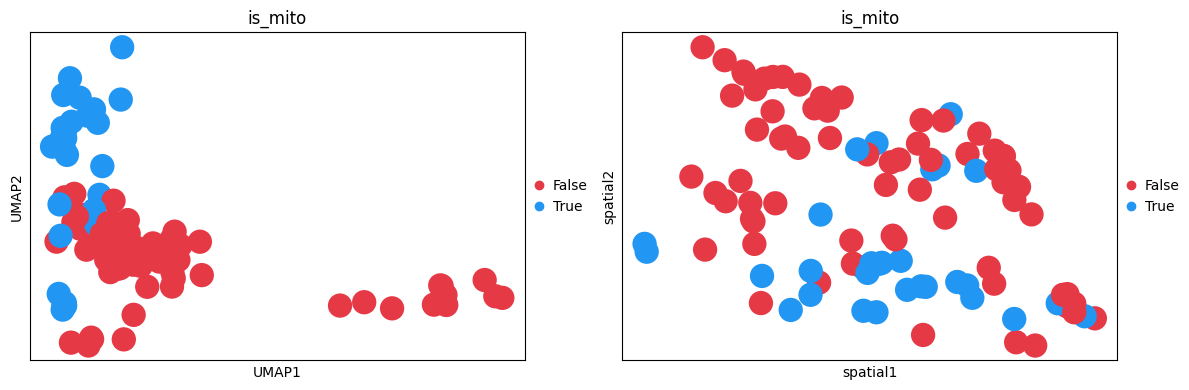

,names,scores,logfoldchanges,pvals,pvals_adj,gene_symbol
0,ENSG00000198727,7.847037,3.436629,4.259804e-15,5.775080e-11,MT-CYB
1,ENSG00000198899,7.785371,3.331416,6.950891e-15,5.775080e-11,MT-ATP6
2,ENSG00000198938,7.785371,3.218037,6.950891e-15,5.775080e-11,MT-CO3
3,ENSG00000198804,7.762246,2.961456,8.343824e-15,5.775080e-11,MT-CO1
4,ENSG00000198712,7.754538,3.138344,8.866574e-15,5.775080e-11,MT-CO2
5,ENSG00000198886,7.746830,3.047837,9.421524e-15,5.775080e-11,MT-ND4
6,ENSG00000198888,7.515581,3.051192,5.665876e-14,2.976851e-10,MT-ND1
7,ENSG00000198763,7.083917,2.877728,1.401360e-12,6.442404e-09,MT-ND2
8,ENSG00000212907,6.844960,2.689362,7.649730e-12,3.126020e-08,MT-ND4L
9,ENSG00000198840,6.744752,3.385742,1.532885e-11,5.637643e-08,MT-ND3


... storing 'zone_x_region_x_ct' as categorical
... storing 'is_mito' as categorical



Analyzing ct=Patch_D2, zone=Caudate


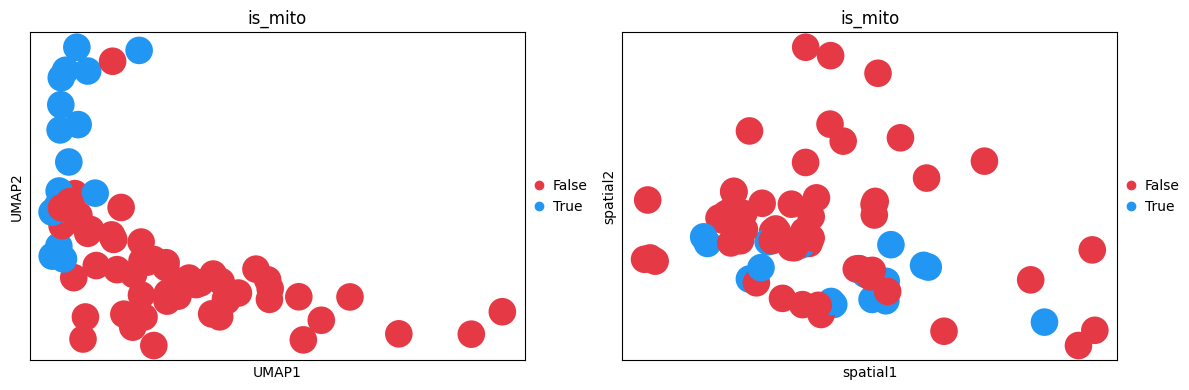

,names,scores,logfoldchanges,pvals,pvals_adj,gene_symbol
0,ENSG00000198727,6.089188,2.731509,1.134850e-09,0.000042,MT-CYB
1,ENSG00000198886,5.964537,2.887930,2.453287e-09,0.000044,MT-ND4
2,ENSG00000198804,5.902212,2.719337,3.586607e-09,0.000044,MT-CO1
3,ENSG00000198938,5.777561,2.463463,7.579129e-09,0.000070,MT-CO3
4,ENSG00000212907,5.441004,2.493676,5.298114e-08,0.000348,MT-ND4L
5,ENSG00000198712,5.428539,2.616531,5.681727e-08,0.000348,MT-CO2
6,ENSG00000198888,5.191702,2.458794,2.083798e-07,0.000991,MT-ND1
7,ENSG00000198786,5.185470,2.574994,2.154708e-07,0.000991,MT-ND5
8,ENSG00000186487,5.079517,0.744308,3.783959e-07,0.001442,MYT1L
9,ENSG00000148408,5.067052,1.204646,4.040244e-07,0.001442,CACNA1B


In [ ]:
df_list = []

ZONE_CT_MAP = {
    "Matrix_D1": "zone",
    "Matrix_D2": "zone",
    "Patch_D1":  "zone_4",
    "Patch_D2":  "zone_4",
    "eMSN_D1D2": "zone_4",
}

LABEL_COL = "ct_for_deg_no_mito"

for ct, zone_var in ZONE_CT_MAP.items():
    # get unique zones for this cell type
    mask_ct = adata_slice.obs[LABEL_COL] == ct
    zones = adata_slice.obs.loc[mask_ct, zone_var].unique()

    for z in zones:
        print(f"\nAnalyzing ct={ct}, zone={z}")

        # cells of this ct AND this zone
        mask = (
            mask_ct
            & (adata_slice.obs[zone_var] == z)
        )
        adata_sub = adata_slice[mask].copy()

        # need both mito and non-mito cells to compare
        adata_sub.obs["is_mito"] = (
            adata_sub.obs["ct_for_deg"] == "-Mito_cluster_patch"
        ).astype(str)

        counts = adata_sub.obs["is_mito"].value_counts()
        if len(counts) < 2 or counts.min() < 3:
            print(f"  Skipping: not enough cells in both groups ({counts.to_dict()})")
            continue

        lmu.plot_umap_spatial(adata_sub, color=["is_mito"], name="", ncols=1)

        res = preprocessing.rank_markers_per_cluster(
            adata_sub, "is_mito", layer="log1p_norm", n_genes=None, markers=None
        )

        for cluster, df in res.items():
            if cluster != "True":  # DEGs for the mito group vs non-mito
                continue

            df = df.merge(
                adata.var[["gene_symbol"]], left_on="names", right_index=True, how="left"
            )
            df = df[np.abs(df["logfoldchanges"]) < 10].copy()

            display(df.head(40))

            # annotate gene types
            df["gene_type"] = "Other"
            for label, gene_list in [
                ("XDP-associated", lmu.xdp_genes),
                ("PRC2 targets", lmu.prc2_genes),
                ("Handsaker et al. genes", lmu.handsaker_genes),
                ("Spatial genes", lmu.spatial_genes),
            ]:
                df.loc[df["gene_symbol"].isin(gene_list), "gene_type"] = label

            df["cell_type"] = ct
            df["zone"] = z
            df["gene_name"] = df["gene_symbol"]

            df_list.append(df)

final_df = pd.concat(df_list, ignore_index=True)
# final_df.to_csv(
#     f"/home/gdallagl/myworkdir/XDP/data/XDP/diseased/{SAMPLE}/adata/"
#     f"DEGs_mito_vs_nonmito_same_ct_same_zone.csv",
#     index=False,
# )